# FinSight — Retailbankanalyse

## Doel

Dit project demonstreert een end-to-end data-analyse van een synthetische retailbankdataset met behulp van Microsoft SQL Server en Python.

De focus ligt op data cleaning, cashflowanalyse, klantsegmentatie, kredietrisico, verdachte transacties, Customer 360-analyse en het genereren van financiële KPI's en business insights.

Alle data in dit project is volledig synthetisch en bevat geen echte klant- of bankgegevens.

## 1 — Setup & Libraries

In [96]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from sqlalchemy.engine import URL

## 2 — SQL Server-verbinding & Data laden

In [ ]:
# Lokale SQL Server-configuratie


server = r"YOUR_SERVER_XX"
database = "FinSight"

connection_string = (
    "DRIVER={ODBC Driver 18 for SQL Server};"
    f"SERVER={server};"
    f"DATABASE={database};"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

connection_url = URL.create(
    "mssql+pyodbc",
    query={"odbc_connect": connection_string}
)

engine = create_engine(connection_url)

print("SQLAlchemy-engine aangemaakt.")

SQLAlchemy-engine aangemaakt.


### 2.1 — Verbinding testen


In [98]:
test = pd.read_sql(
    "SELECT TOP 5 * FROM dbo.vw_customer_summary",
    engine
)

display(test)

,customer_id,country,age_group,segment,annual_income_eur,risk_score,acquisition_channel,join_date,digital_active,aantal_accounts,...,totaal_verstrekt_krediet_eur,openstaand_krediet_eur,max_days_past_due,aantal_defaults,aantal_transacties,totale_inflow_eur,totale_outflow_eur,netto_cashflow_eur,suspicious_transacties,internationale_transacties
0,C00001,France,45-54,Senior,66500,670,Paid Search,2025-08-13,True,1,...,0,0.000000,0,0,1,0.000000,51.639999,-51.639999,0,0
1,C00002,Netherlands,35-44,Young Professional,46100,665,Organic Web,2025-01-23,True,2,...,18800,9508.299805,0,0,5,69.029999,1736.540009,-1667.510010,0,0
2,C00003,France,45-54,Young Professional,56100,703,Organic Web,2021-01-16,False,3,...,39700,10912.690430,0,0,9,919.959991,736.040024,183.919968,0,0
3,C00004,Belgium,65+,Young Professional,37700,627,Referral,2019-07-18,True,2,...,0,0.000000,0,0,5,2512.020050,133.279999,2378.740051,0,0
4,C00005,Luxembourg,55-64,Affluent,77300,750,Branch,2024-12-26,True,2,...,0,0.000000,0,0,1,0.000000,253.809998,-253.809998,0,0


### 2.2 — Analytische datasets laden

In [99]:
customers = pd.read_sql(
    "SELECT * FROM dbo.vw_customer_summary",
    engine
)

monthly = pd.read_sql(
    '''
    SELECT *
    FROM dbo.vw_monthly_financial_kpis
    ORDER BY maand
    ''',
    engine
)

risk = pd.read_sql(
    "SELECT * FROM dbo.vw_risk_monitoring",
    engine
)

transactions = pd.read_sql(
    "SELECT * FROM dbo.transactions_clean",
    engine
)

print("Datasets geladen:")
print(f"Klanten: {customers.shape}")
print(f"Maandelijkse KPI's: {monthly.shape}")
print(f"Risicomonitoring: {risk.shape}")
print(f"Transacties: {transactions.shape}")

Datasets geladen:
Klanten: (2500, 24)
Maandelijkse KPI's: (32, 10)
Risicomonitoring: (2500, 11)
Transacties: (10000, 12)


## 3 — Datakwaliteit & Beschrijvende Statistiek

### 3.1 — Ontbrekende Waarden

In [100]:
print("CUSTOMERS")
print(customers.isna().sum())
 
print("\nMONTHLY")
print(monthly.isna().sum())
 
print("\nRISK")
print(risk.isna().sum())
 
print("\nTRANSACTIONS")
print(transactions.isna().sum())

CUSTOMERS
customer_id                     0
country                         0
age_group                       0
segment                         0
annual_income_eur               0
risk_score                      0
acquisition_channel             0
join_date                       0
digital_active                  0
aantal_accounts                 0
aantal_accounttypes             0
totaal_opening_balance_eur      0
hoogste_credit_limit_eur        0
aantal_leningen                 0
totaal_verstrekt_krediet_eur    0
openstaand_krediet_eur          0
max_days_past_due               0
aantal_defaults                 0
aantal_transacties              0
totale_inflow_eur               0
totale_outflow_eur              0
netto_cashflow_eur              0
suspicious_transacties          0
internationale_transacties      0
dtype: int64

MONTHLY
maand                             0
aantal_transacties                0
inflow_eur                        0
outflow_eur                       0
netto_ca

### 3.2 — Checken op duplicates

In [101]:
print("Customers duplicates:", customers.duplicated().sum())
print("Maandly duplicates:", monthly.duplicated().sum())
print("Risk duplicates:", risk.duplicated().sum())
print("Transactions duplicates:", transactions.duplicated().sum())

Customers duplicates: 0
Maandly duplicates: 0
Risk duplicates: 0
Transactions duplicates: 0


### 3.3 — Beschrijvende Statistiek: Klanten

In [102]:
customers.describe().T

,count,mean,std,min,25%,50%,75%,max
annual_income_eur,2500.0,53612.360000,21157.668823,16000.000000,39100.000000,51050.000000,64200.000000,165800.000000
risk_score,2500.0,682.376400,67.099780,441.000000,637.000000,683.000000,729.000000,850.000000
aantal_accounts,2500.0,1.635200,0.656577,1.000000,1.000000,2.000000,2.000000,3.000000
aantal_accounttypes,2500.0,1.635200,0.656577,1.000000,1.000000,2.000000,2.000000,3.000000
totaal_opening_balance_eur,2500.0,9091.266878,10285.177759,-4528.899994,2000.819977,5089.610123,13339.762894,74778.469727
hoogste_credit_limit_eur,2500.0,1823.280000,3577.369015,0.000000,0.000000,0.000000,2000.000000,15000.000000
aantal_leningen,2500.0,0.280000,0.449089,0.000000,0.000000,0.000000,1.000000,1.000000
totaal_verstrekt_krediet_eur,2500.0,5228.200000,10075.082316,0.000000,0.000000,0.000000,5700.000000,45000.000000
openstaand_krediet_eur,2500.0,3134.939246,6987.300863,0.000000,0.000000,0.000000,1480.649994,42438.050781
max_days_past_due,2500.0,0.114000,2.698132,0.000000,0.000000,0.000000,0.000000,90.000000


### 3.4 — Beschrijvende Statistiek: Transacties

In [103]:
transactions.describe().T

,count,mean,min,25%,50%,75%,max,std
transaction_datetime,10000,2025-05-01 13:52:52.524800,2024-01-01 01:09:38,2024-08-31 03:05:51.250000,2025-05-07 15:53:43.500000,2025-12-26 09:30:00.750000,2026-08-31 20:54:14,NaN
amount_eur,10000.0,111.089361,-4173.359863,-152.339996,-55.530001,139.747498,10111.769531,873.986634


### 3.5 — Beschrijvende Statistiek: Maandelijkse KPI's

In [104]:
monthly.describe().T

,count,mean,std,min,25%,50%,75%,max
aantal_transacties,32.0,312.500000,23.002104,253.00,304.0000,313.500,325.0000,363.00
inflow_eur,32.0,80279.068437,14364.849877,51231.86,68298.5550,79250.245,95176.9525,100371.97
outflow_eur,32.0,45563.643125,6662.839406,28737.80,42047.6825,45776.990,49328.8000,59974.60
netto_cashflow_eur,32.0,34715.425312,16691.263416,2749.17,22059.5875,36209.405,48433.2725,68783.58
gemiddeld_transactiebedrag_eur,32.0,403.105937,42.415637,341.89,367.6550,404.120,441.4125,469.70
suspicious_transacties,32.0,2.031250,1.402403,0.00,1.0000,2.000,3.0000,5.00
suspicious_rate_pct,32.0,0.643438,0.430795,0.00,0.3275,0.625,0.9625,1.38
internationale_transacties,32.0,5.968750,2.583875,1.00,4.0000,6.000,8.0000,11.00
international_rate_pct,32.0,1.904062,0.812356,0.40,1.2275,1.860,2.6150,3.23


### 3.6 — Beschrijvende Statistiek: Risicomonitoring

In [105]:
risk.describe().T

,count,mean,std,min,25%,50%,75%,max
annual_income_eur,2500.0,53612.360000,21157.668823,16000.0,39100.0,51050.0,64200.000000,165800.000000
risk_score,2500.0,682.376400,67.099780,441.0,637.0,683.0,729.000000,850.000000
aantal_leningen,2500.0,0.280000,0.449089,0.0,0.0,0.0,1.000000,1.000000
openstaand_krediet_eur,2500.0,3134.939246,6987.300863,0.0,0.0,0.0,1480.649994,42438.050781
max_days_past_due,2500.0,0.114000,2.698132,0.0,0.0,0.0,0.000000,90.000000
aantal_defaults,2500.0,0.000800,0.028279,0.0,0.0,0.0,0.000000,1.000000
aantal_transacties,2500.0,4.000000,2.644768,0.0,2.0,4.0,6.000000,16.000000
suspicious_transacties,2500.0,0.026000,0.161662,0.0,0.0,0.0,0.000000,2.000000


### 3.7 — Verdeling van Monitoringniveaus

In [106]:
#checken omdat deze categorisch zijn bij Monitoringniveau
risk["monitoring_level"].value_counts()

monitoring_level
Normal    2173
Medium     325
High         2
Name: count, dtype: int64

### 3.8 — Verdeling van Monitoringniveaus (%)

In [107]:
#monitoring levels als percentage
(
    risk["monitoring_level"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

monitoring_level
Normal    86.92
Medium    13.00
High       0.08
Name: proportion, dtype: float64

## 4 — Cashflow- & Transactieanalyse

### 4.1 — Voorbereiding financiële visualisaties

In [108]:
from pathlib import Path
 
# Map voor portfolio-afbeeldingen
project_root = Path.cwd()
if project_root.name.lower() == "notebooks":
    project_root = project_root.parent

images_dir = project_root / "Images"
images_dir.mkdir(parents=True, exist_ok=True)
 

# Datums expliciet converteren voor reproduceerbare tijdreeksanalyse
monthly["maand"] = pd.to_datetime(monthly["maand"])
transactions["transaction_datetime"] = pd.to_datetime(
    transactions["transaction_datetime"]
)

# Zorg dat de relevante kolommen numeriek zijn
monthly["inflow_eur"] = pd.to_numeric(monthly["inflow_eur"])
monthly["outflow_eur"] = pd.to_numeric(monthly["outflow_eur"])
monthly["netto_cashflow_eur"] = pd.to_numeric(monthly["netto_cashflow_eur"])
monthly["aantal_transacties"] = pd.to_numeric(monthly["aantal_transacties"])
 
transactions["amount_eur"] = pd.to_numeric(transactions["amount_eur"])
 
# Absolute transactiewaarde
transactions["abs_amount_eur"] = transactions["amount_eur"].abs()
 
# Sorteren op maand
monthly = monthly.sort_values("maand")
 
monthly.head()

,maand,aantal_transacties,inflow_eur,outflow_eur,netto_cashflow_eur,gemiddeld_transactiebedrag_eur,suspicious_transacties,suspicious_rate_pct,internationale_transacties,international_rate_pct
0,2024-01-01,314,73440.28,42082.37,31357.91,367.91,4,1.27,3,0.96
1,2024-02-01,294,71877.49,40548.10,31329.39,382.40,0,0.00,8,2.72
2,2024-03-01,333,73567.29,48152.60,25414.69,365.53,3,0.90,3,0.90
3,2024-04-01,320,68230.83,42358.97,25871.86,345.59,2,0.63,8,2.50
4,2024-05-01,304,68321.13,46133.50,22187.63,376.50,1,0.33,4,1.32


### 4.2 — Maandelijkse flow vs outflow

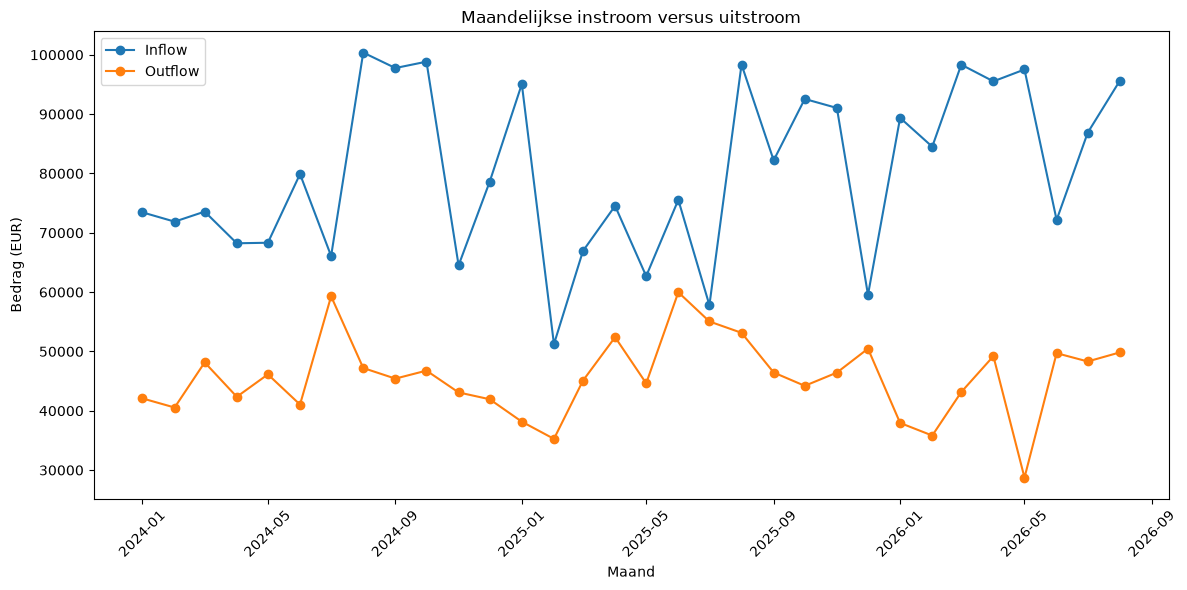

In [109]:
plt.figure(figsize=(12, 6))
 
plt.plot(
    monthly["maand"],
    monthly["inflow_eur"],
    marker="o",
    label="Inflow"
)
 
plt.plot(
    monthly["maand"],
    monthly["outflow_eur"],
    marker="o",
    label="Outflow"
)
 
plt.title("Maandelijkse instroom versus uitstroom")
plt.xlabel("Maand")
plt.ylabel("Bedrag (EUR)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
 
plt.savefig(
    images_dir / "monthly_inflow_vs_outflow.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()

### 4.3 — Netto Cashflow doorheen de tijd

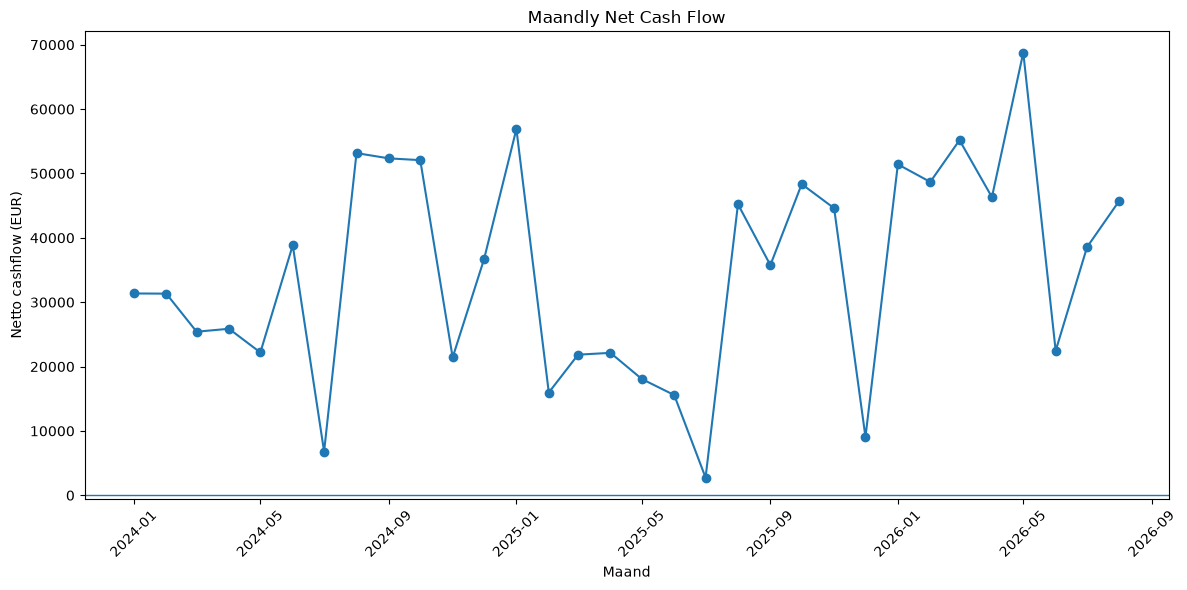

In [110]:
plt.figure(figsize=(12, 6))
 
plt.plot(
    monthly["maand"],
    monthly["netto_cashflow_eur"],
    marker="o"
)
 
plt.axhline(
    y=0,
    linewidth=1
)
 
plt.title("Maandly Net Cash Flow")
plt.xlabel("Maand")
plt.ylabel("Netto cashflow (EUR)")
plt.xticks(rotation=45)
plt.tight_layout()
 
plt.savefig(
    images_dir / "monthly_net_cashflow.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()

### 4.4 — Totale uitgaven per categorie

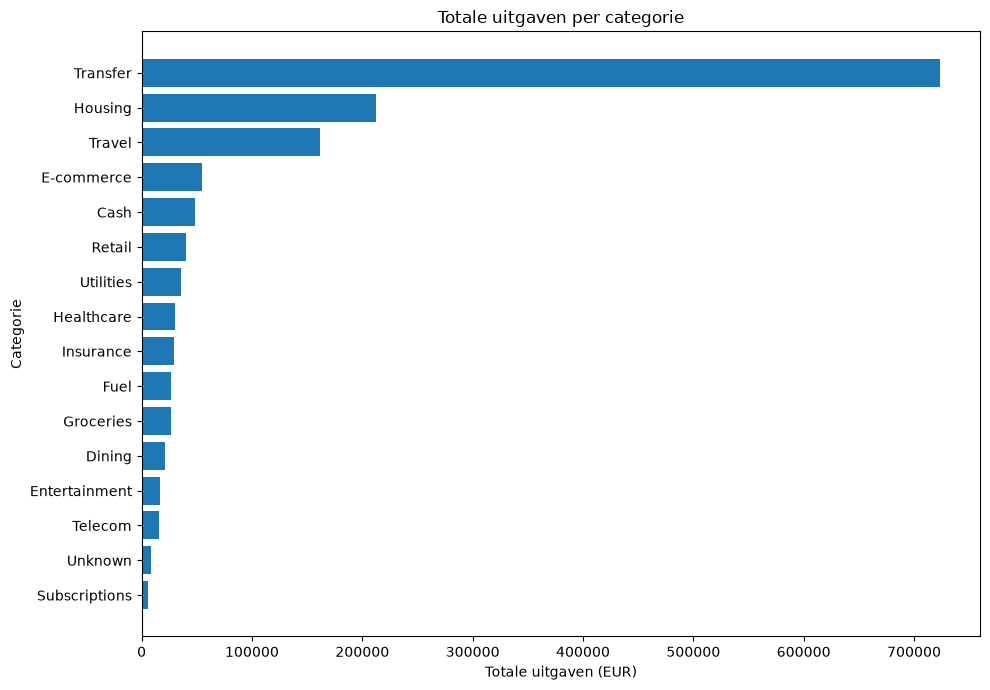

In [111]:
category_spending = (
    transactions[
        transactions["flow_direction"] == "Outflow"
    ]
    .groupby("category")["amount_eur"]
    .sum()
    .abs()
    .sort_values(ascending=True)
)
 
plt.figure(figsize=(10, 7))
 
plt.barh(
    category_spending.index,
    category_spending.values
)
 
plt.title("Totale uitgaven per categorie")
plt.xlabel("Totale uitgaven (EUR)")
plt.ylabel("Categorie")
plt.tight_layout()
 
plt.savefig(
    images_dir / "spending_by_category.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()

In [112]:
category_spending.sort_values(ascending=False)

category
Transfer         723596.109501
Housing          212848.659637
Travel           161895.250103
E-commerce        54393.470018
Cash              48430.000000
Retail            40588.730040
Utilities         35739.780048
Healthcare        30619.410029
Insurance         29535.030006
Fuel              27007.620087
Groceries         26447.830025
Dining            21014.789991
Entertainment     16397.299999
Telecom           15700.669994
Unknown            8150.979992
Subscriptions      5670.950007
Name: amount_eur, dtype: float64

### 4.5 — Aantal transacties per kanaal

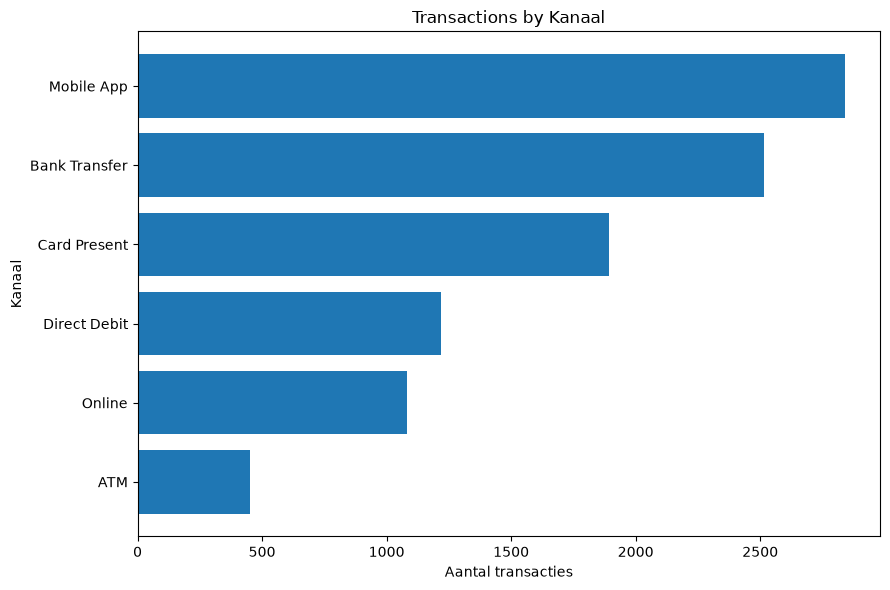

In [113]:
channel_counts = (
    transactions["channel"]
    .value_counts()
    .sort_values(ascending=True)
)
 
plt.figure(figsize=(9, 6))
 
plt.barh(
    channel_counts.index,
    channel_counts.values
)
 
plt.title("Transactions by Kanaal")
plt.xlabel("Aantal transacties")
plt.ylabel("Kanaal")
plt.tight_layout()
 
plt.savefig(
    images_dir / "transactions_by_channel.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()

### 4.6 — Verdeling van transactiewaarden

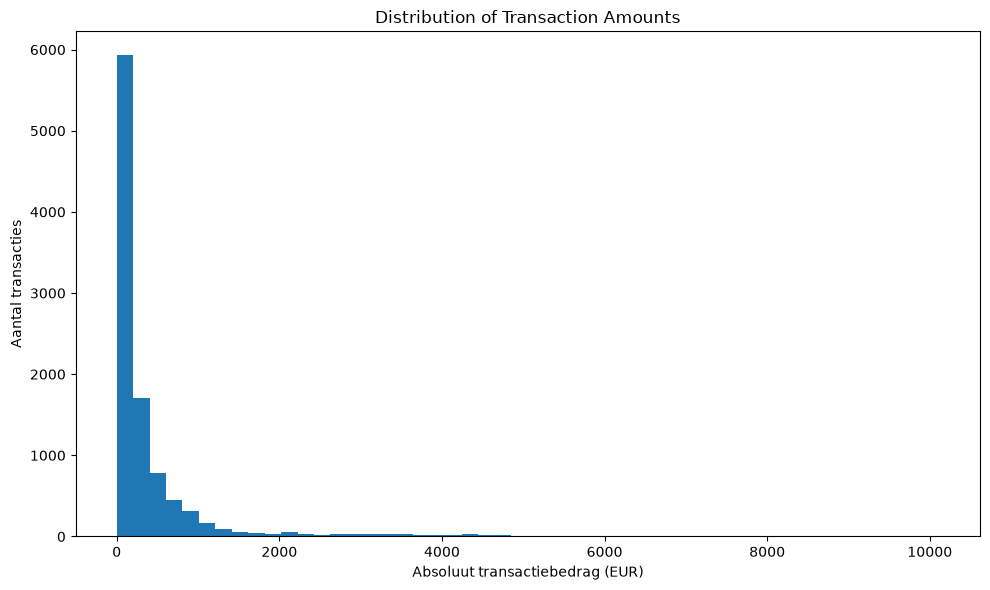

In [114]:
plt.figure(figsize=(10, 6))
 
plt.hist(
    transactions["abs_amount_eur"],
    bins=50
)
 
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Absoluut transactiebedrag (EUR)")
plt.ylabel("Aantal transacties")
plt.tight_layout()
 
plt.savefig(
    images_dir / "transaction_amount_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()

### 4.7 — Transacties zonder extreme bovenste 1%

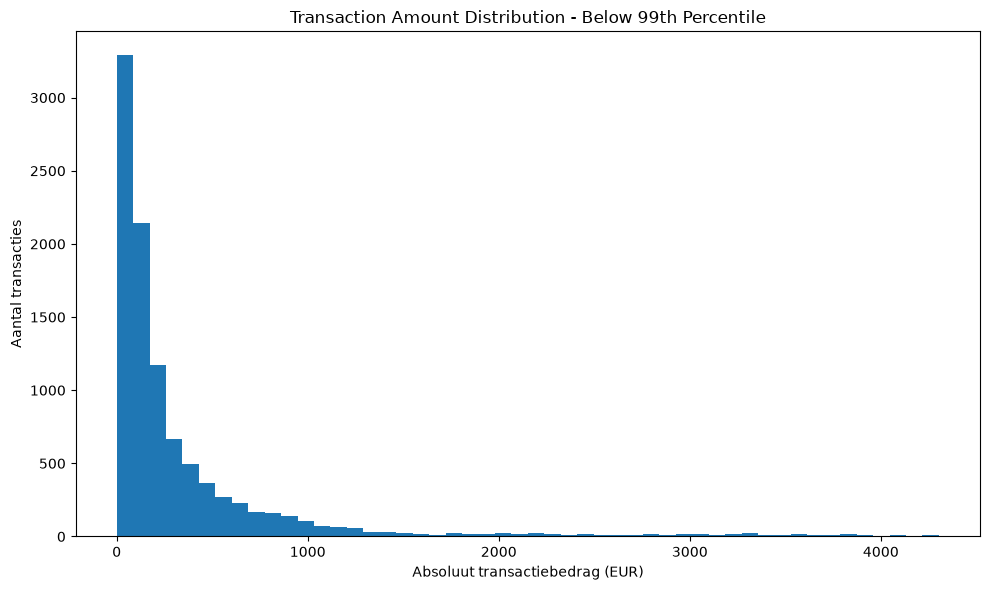

In [115]:
p99 = transactions["abs_amount_eur"].quantile(0.99)
 
transactions_trimmed = transactions[
    transactions["abs_amount_eur"] <= p99
]
 
plt.figure(figsize=(10, 6))
 
plt.hist(
    transactions_trimmed["abs_amount_eur"],
    bins=50
)
 
plt.title("Transaction Amount Distribution - Below 99th Percentile")
plt.xlabel("Absoluut transactiebedrag (EUR)")
plt.ylabel("Aantal transacties")
plt.tight_layout()
 
plt.savefig(
    images_dir / "transaction_amount_distribution_p99.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()

### 4.8 — Maandelijkse Transactievolume

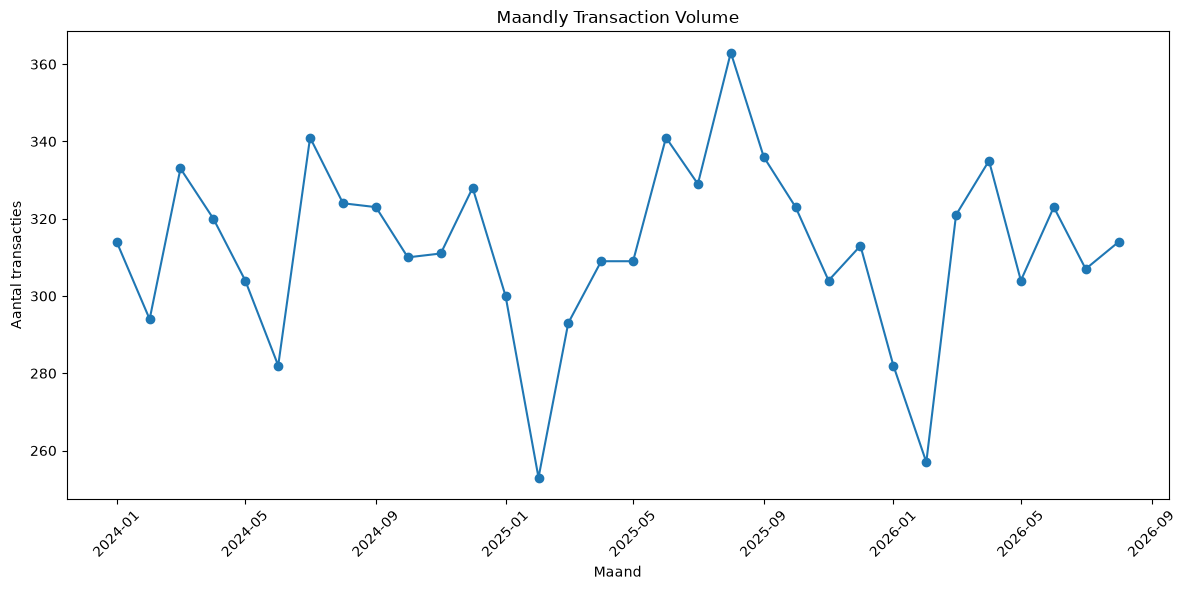

In [116]:
plt.figure(figsize=(12, 6))
 
plt.plot(
    monthly["maand"],
    monthly["aantal_transacties"],
    marker="o"
)
 
plt.title("Maandly Transaction Volume")
plt.xlabel("Maand")
plt.ylabel("Aantal transacties")
plt.xticks(rotation=45)
plt.tight_layout()
 
plt.savefig(
    images_dir / "monthly_transaction_volume.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()

### 4.9 — Maandelijkse cashflow-KPI's samenvatten

In [117]:
cashflow_summary = pd.Series({
    "Total Inflow EUR":
        monthly["inflow_eur"].sum(),
 
    "Total Outflow EUR":
        monthly["outflow_eur"].sum(),
 
    "Net Cash Flow EUR":
        monthly["netto_cashflow_eur"].sum(),
 
    "Average Transaction EUR":
        transactions["abs_amount_eur"].mean(),
 
    "Median Transaction EUR":
        transactions["abs_amount_eur"].median(),
 
    "Largest Transaction EUR":
        transactions["abs_amount_eur"].max(),
 
    "Total Transactions":
        len(transactions)
})
 
cashflow_summary.round(2)

Total Inflow EUR           2568930.19
Total Outflow EUR          1458036.58
Net Cash Flow EUR          1110893.61
Average Transaction EUR        402.70
Median Transaction EUR         150.00
Largest Transaction EUR      10111.77
Total Transactions           10000.00
dtype: float64

## 5 — Klantsegmentatie

### 5.1 — Aantal klanten

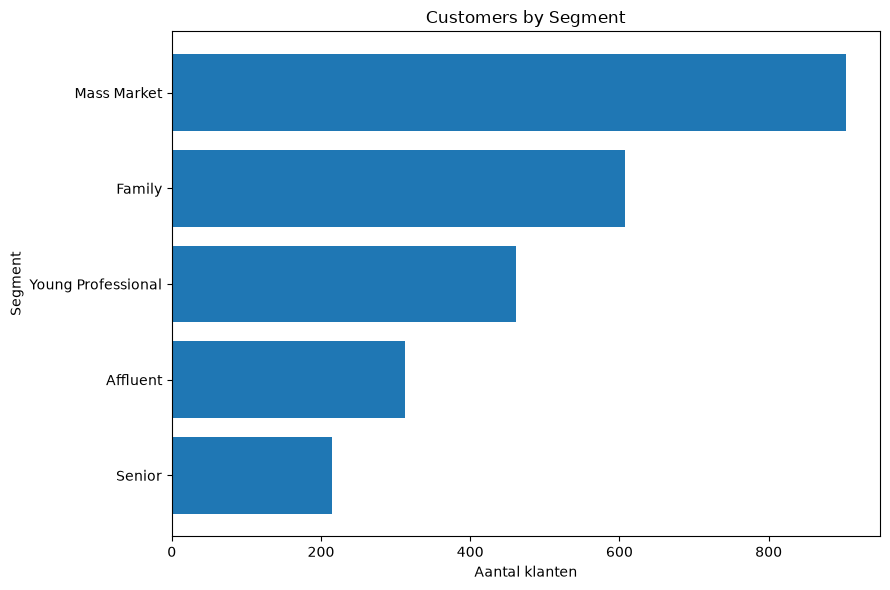

In [118]:
segment_counts = (
    customers["segment"]
    .value_counts()
    .sort_values(ascending=True)
)
 
plt.figure(figsize=(9, 6))
 
plt.barh(
    segment_counts.index,
    segment_counts.values
)
 
plt.title("Customers by Segment")
plt.xlabel("Aantal klanten")
plt.ylabel("Segment")
plt.tight_layout()
 
plt.savefig(
    images_dir / "customers_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()

### 5.2 — Gemiddeld jaarinkomen per segment

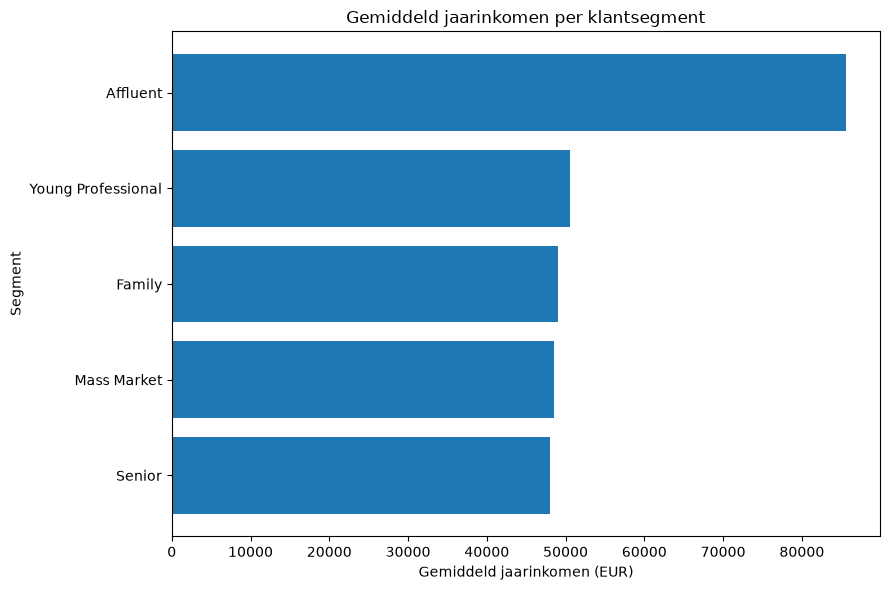

segment
Senior                48071.16
Mass Market           48538.38
Family                48987.01
Young Professional    50572.89
Affluent              85636.86
Name: annual_income_eur, dtype: float64


In [119]:
income_by_segment = (
    customers
    .groupby("segment")["annual_income_eur"]
    .mean()
    .sort_values(ascending=True)
)
 
plt.figure(figsize=(9, 6))
 
plt.barh(
    income_by_segment.index,
    income_by_segment.values
)
 
plt.title("Gemiddeld jaarinkomen per klantsegment")
plt.xlabel("Gemiddeld jaarinkomen (EUR)")
plt.ylabel("Segment")
plt.tight_layout()
 
plt.savefig(
    images_dir / "average_income_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()
 
print(income_by_segment.round(2))

### 5.3 — Gemiddelde risicoscore per segment

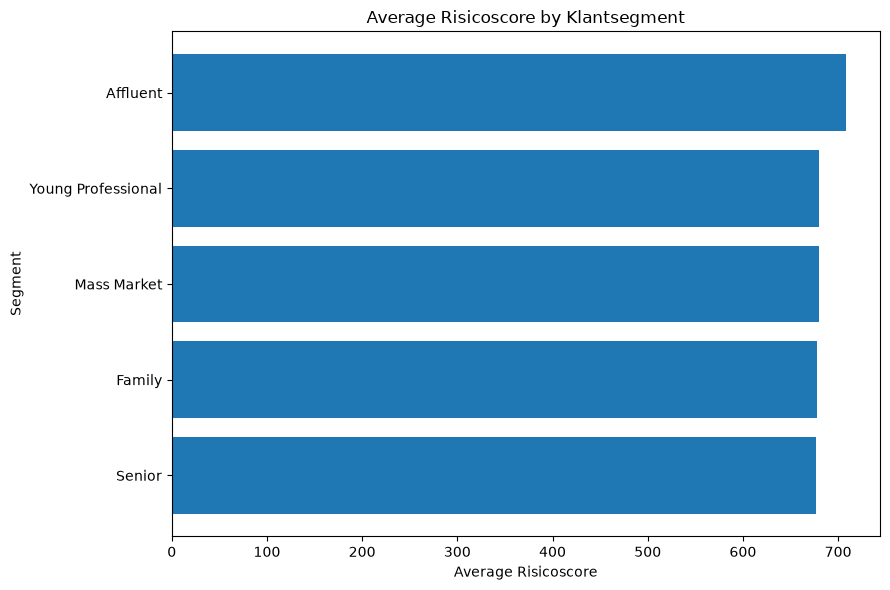

segment
Senior                677.24
Family                677.34
Mass Market           679.42
Young Professional    679.49
Affluent              708.57
Name: risk_score, dtype: float64


In [120]:
risk_by_segment = (
    customers
    .groupby("segment")["risk_score"]
    .mean()
    .sort_values(ascending=True)
)
 
plt.figure(figsize=(9, 6))
 
plt.barh(
    risk_by_segment.index,
    risk_by_segment.values
)
 
plt.title("Average Risicoscore by Klantsegment")
plt.xlabel("Average Risicoscore")
plt.ylabel("Segment")
plt.tight_layout()
 
plt.savefig(
    images_dir / "average_risk_score_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()
 
print(risk_by_segment.round(2))

### 5.4 — Gemiddeld aantal accounts per segment

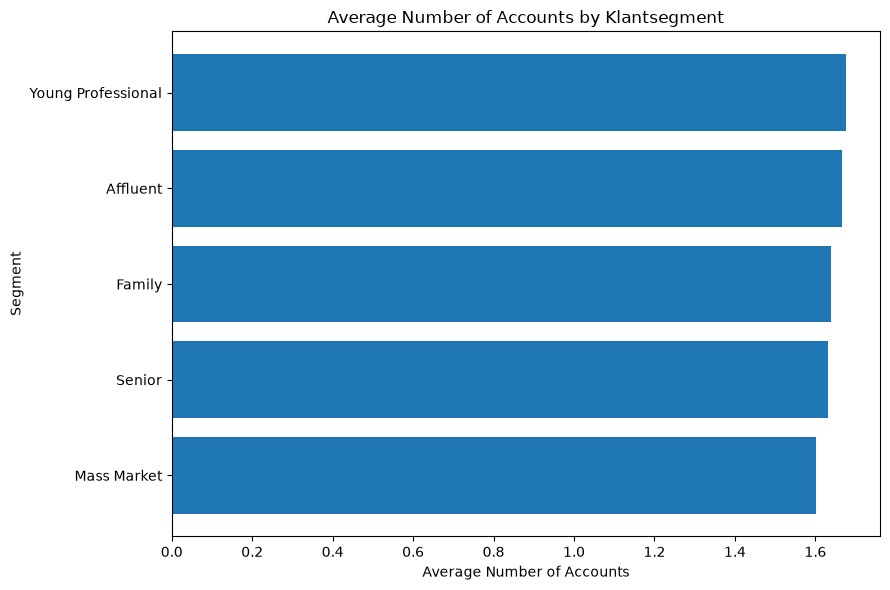

In [121]:
accounts_by_segment = (
    customers
    .groupby("segment")["aantal_accounts"]
    .mean()
    .sort_values(ascending=True)
)
 
plt.figure(figsize=(9, 6))
 
plt.barh(
    accounts_by_segment.index,
    accounts_by_segment.values
)
 
plt.title("Average Number of Accounts by Klantsegment")
plt.xlabel("Average Number of Accounts")
plt.ylabel("Segment")
plt.tight_layout()
 
plt.savefig(
    images_dir / "average_accounts_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()

### 5.5 — Gemiddeld aantal accounts en leningen per segment

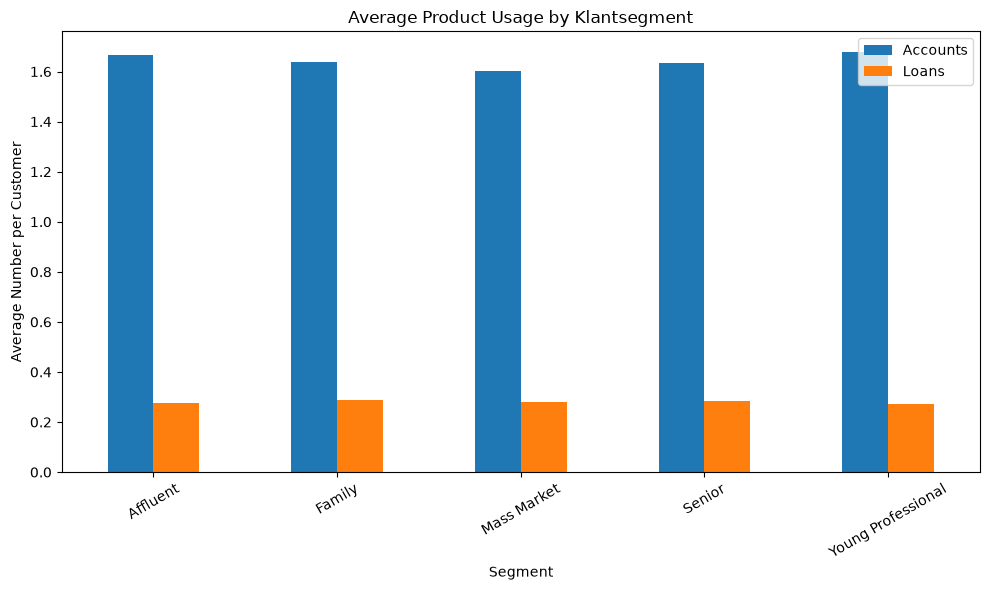

In [122]:
product_usage = (
    customers
    .groupby("segment")[
        ["aantal_accounts", "aantal_leningen"]
    ]
    .mean()
    .sort_index()
)
 
product_usage.plot(
    kind="bar",
    figsize=(10, 6)
)
 
plt.title("Average Product Usage by Klantsegment")
plt.xlabel("Segment")
plt.ylabel("Average Number per Customer")
plt.xticks(rotation=30)
plt.legend(["Accounts", "Loans"])
plt.tight_layout()
 
plt.savefig(
    images_dir / "product_usage_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()

### 5.6 — Gemiddelde netto cashflow per segment

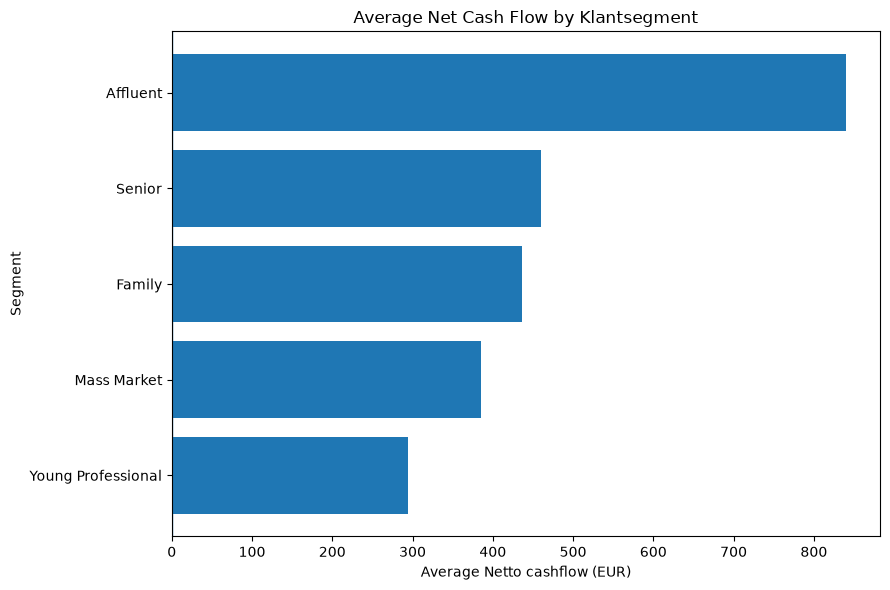

In [123]:
cashflow_by_segment = (
    customers
    .groupby("segment")["netto_cashflow_eur"]
    .mean()
    .sort_values(ascending=True)
)
 
plt.figure(figsize=(9, 6))
 
plt.barh(
    cashflow_by_segment.index,
    cashflow_by_segment.values
)
 
plt.axvline(
    x=0,
    linewidth=1
)
 
plt.title("Average Net Cash Flow by Klantsegment")
plt.xlabel("Average Netto cashflow (EUR)")
plt.ylabel("Segment")
plt.tight_layout()
 
plt.savefig(
    images_dir / "net_cashflow_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()

### 5.7 — Digitale adoptie per segment

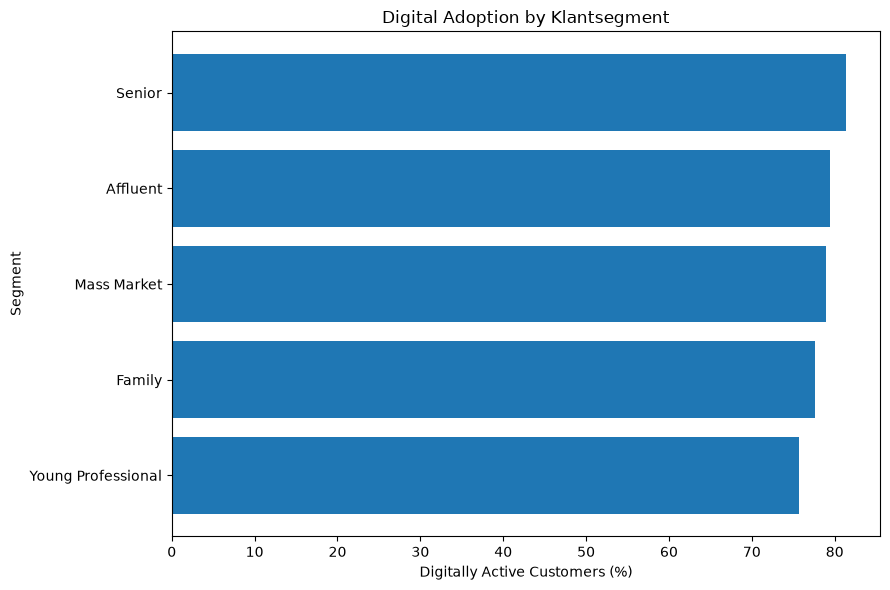

segment
Young Professional    75.70
Family                77.63
Mass Market           78.98
Affluent              79.49
Senior                81.40
Name: digital_active, dtype: float64


In [124]:
digital_adoption = (
    customers
    .groupby("segment")["digital_active"]
    .mean()
    .mul(100)
    .sort_values(ascending=True)
)
 
plt.figure(figsize=(9, 6))
 
plt.barh(
    digital_adoption.index,
    digital_adoption.values
)
 
plt.title("Digital Adoption by Klantsegment")
plt.xlabel("Digitally Active Customers (%)")
plt.ylabel("Segment")
plt.tight_layout()
 
plt.savefig(
    images_dir / "digital_adoption_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()
 
print(digital_adoption.round(2))

### 5.8 — Inkomensverdeling per segment

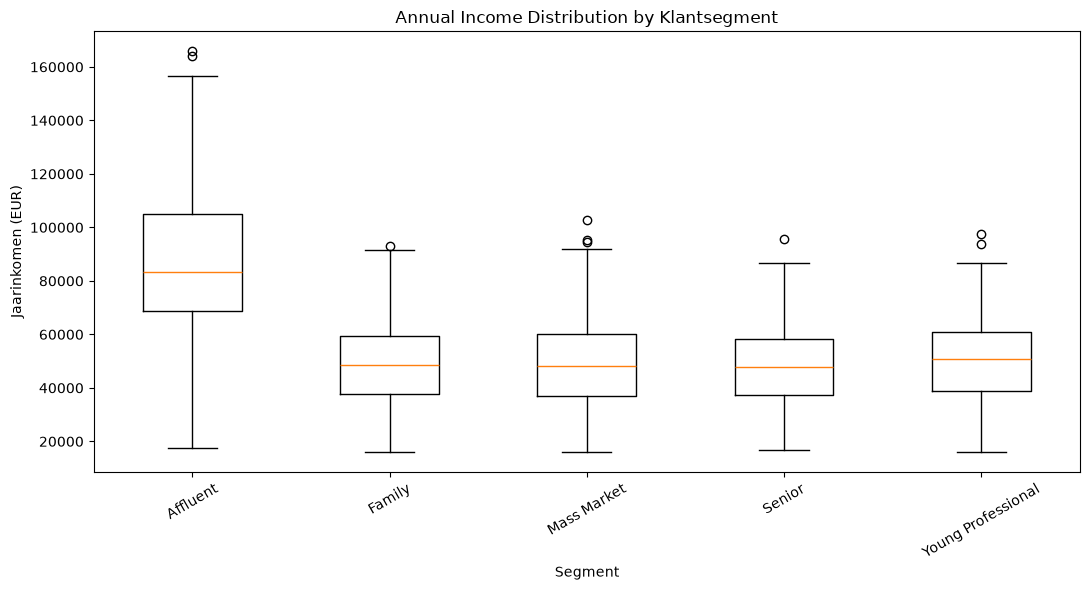

In [125]:
segment_names = sorted(
    customers["segment"]
    .dropna()
    .unique()
)
 
income_groups = [
    customers.loc[
        customers["segment"] == segment,
        "annual_income_eur"
    ]
    for segment in segment_names
]
 
plt.figure(figsize=(11, 6))
 
plt.boxplot(
    income_groups,
    tick_labels=segment_names,
    showfliers=True
)
 
plt.title("Annual Income Distribution by Klantsegment")
plt.xlabel("Segment")
plt.ylabel("Jaarinkomen (EUR)")
plt.xticks(rotation=30)
plt.tight_layout()
 
plt.savefig(
    images_dir / "income_distribution_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()

### 5.9 — Gecombineerd segmentoverzicht als tabel

In [126]:
segment_summary = (
    customers
    .groupby("segment")
    .agg(
        customers=("customer_id", "count"),
        avg_income_eur=("annual_income_eur", "mean"),
        avg_risk_score=("risk_score", "mean"),
        avg_accounts=("aantal_accounts", "mean"),
        avg_loans=("aantal_leningen", "mean"),
        avg_net_cashflow_eur=("netto_cashflow_eur", "mean"),
        avg_outstanding_credit_eur=("openstaand_krediet_eur", "mean"),
        suspicious_transactions=("suspicious_transacties", "sum"),
        digital_adoption_pct=("digital_active", "mean")
    )
)
 
segment_summary["digital_adoption_pct"] *= 100
 
display(
    segment_summary.round(2)
)

,customers,avg_income_eur,avg_risk_score,avg_accounts,avg_loans,avg_net_cashflow_eur,avg_outstanding_credit_eur,suspicious_transactions,digital_adoption_pct
segment,,,,,,,,,
Affluent,312,85636.86,708.57,1.67,0.28,840.37,3506.47,6,79.49
Family,608,48987.01,677.34,1.64,0.29,436.74,3203.93,20,77.63
Mass Market,904,48538.38,679.42,1.60,0.28,385.39,3022.17,20,78.98
Senior,215,48071.16,677.24,1.63,0.28,459.59,2936.12,7,81.40
Young Professional,461,50572.89,679.49,1.68,0.27,294.92,3106.36,12,75.70


## 6 — Kredietrisicoanalyse

### 6.1 — Loan dataset inladen en voorbereiden

In [127]:
loans = pd.read_sql(
    "SELECT * FROM dbo.loans_raw",
    engine
)

loans["origination_date"] = pd.to_datetime(
    loans["origination_date"]
)

# BIT-kolom veilig omzetten naar integer 0/1
loans["default_flag"] = (
    loans["default_flag"]
    .astype(int)
)

# Risicogroepen maken volgens dezelfde logica als in SQL
loans["risk_group"] = pd.cut(
    loans["customer_risk_score"],
    bins=[
        -float("inf"),
        600,
        700,
        float("inf")
    ],
    labels=[
        "High Risk",
        "Medium Risk",
        "Low Risk"
    ],
    right=False
)

print("Aantal leningen:", len(loans))

display(loans.head())

Aantal leningen: 700


,loan_id,customer_id,origination_date,original_principal_eur,interest_rate_pct,term_months,monthly_payment_eur,outstanding_balance_eur,days_past_due,loan_status,default_flag,customer_risk_score,risk_group
0,1.0,C01277,2026-04-10,36200,8.09,48,885.280029,33719.628906,0,Current,0,626,Medium Risk
1,2.0,C00918,2025-07-22,21000,9.37,48,526.280029,15653.919922,0,Current,0,699,Medium Risk
2,3.0,C02323,2026-03-03,14000,9.84,72,258.230011,13138.870117,0,Current,0,531,High Risk
3,4.0,C02194,2022-08-20,14300,3.71,36,420.350006,2391.870117,0,Current,0,731,Low Risk
4,5.0,C00787,2023-11-19,2700,6.15,48,63.599998,820.469971,0,Current,0,768,Low Risk


### 6.2 — Descriptive statistics leningportefeuille

In [128]:
display(
    loans[
        [
            "original_principal_eur",
            "interest_rate_pct",
            "term_months",
            "monthly_payment_eur",
            "outstanding_balance_eur",
            "days_past_due",
            "customer_risk_score"
        ]
    ]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
original_principal_eur,700.0,18672.142857,10559.975641,2700.00,10000.000000,17550.000000,26325.000000,45000.000000
interest_rate_pct,700.0,7.225771,1.773367,3.50,6.030000,7.180000,8.385000,12.800000
term_months,700.0,47.297143,17.107177,24.00,36.000000,48.000000,60.000000,72.000000
monthly_payment_eur,700.0,517.066086,363.361205,48.23,245.437500,434.645004,690.475006,1976.500000
outstanding_balance_eur,700.0,11196.211592,9173.897269,99.00,3573.757507,9034.120117,16461.492676,42438.050781
days_past_due,700.0,0.407143,5.089888,0.00,0.000000,0.000000,0.000000,90.000000
customer_risk_score,700.0,680.758571,68.141654,488.00,634.750000,680.000000,728.000000,850.000000


### 6.3 — Verdeling van customer risk scores

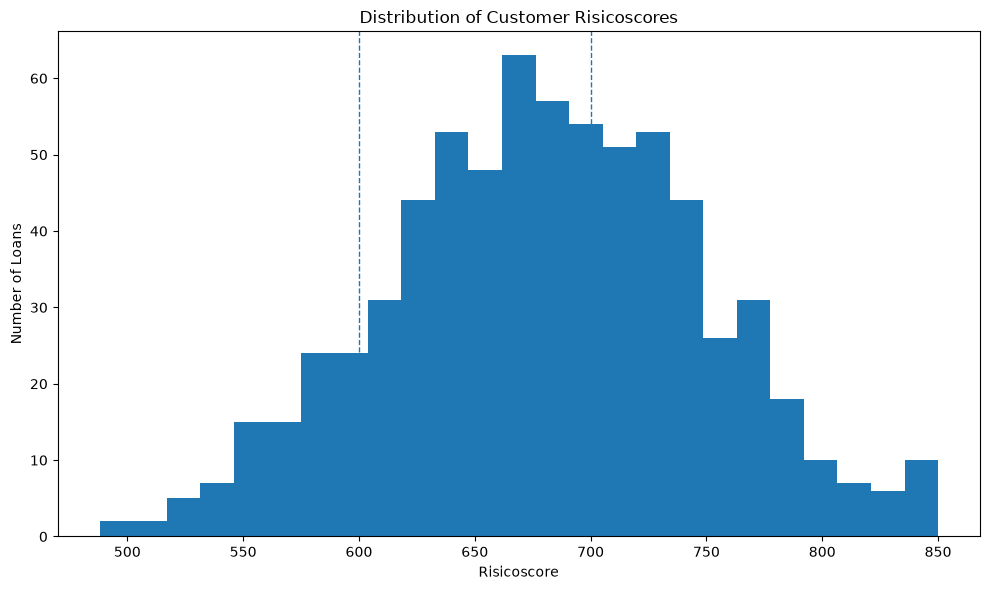

In [129]:
plt.figure(figsize=(10, 6))
 
plt.hist(
    loans["customer_risk_score"],
    bins=25
)
 
plt.axvline(
    x=600,
    linestyle="--",
    linewidth=1
)
 
plt.axvline(
    x=700,
    linestyle="--",
    linewidth=1
)
 
plt.title("Distribution of Customer Risicoscores")
plt.xlabel("Risicoscore")
plt.ylabel("Number of Loans")
plt.tight_layout()
 
plt.savefig(
    images_dir / "risk_score_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()

### 6.4 — Aantal leningen per loan status

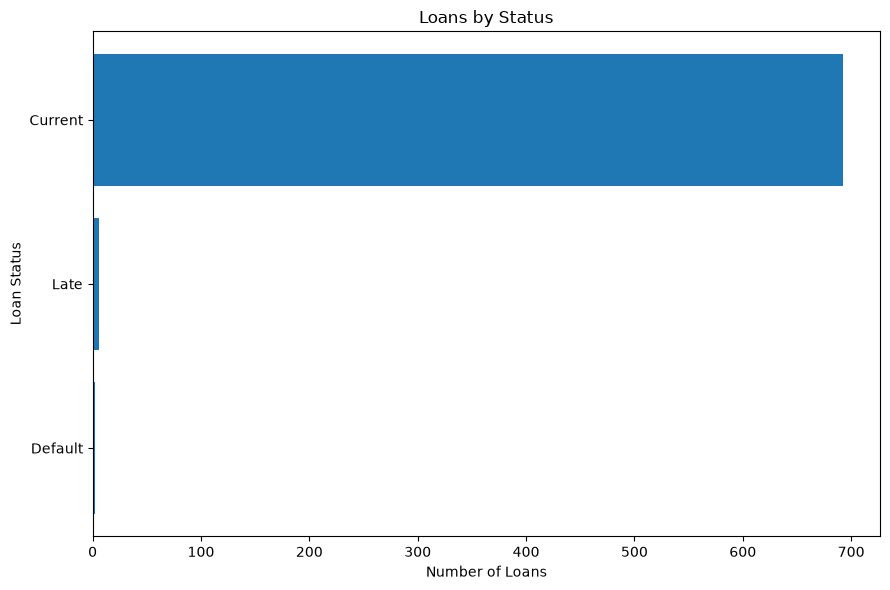

loan_status
Default      2
Late         6
Current    692
Name: count, dtype: int64


In [130]:
loan_status_counts = (
    loans["loan_status"]
    .value_counts()
    .sort_values(ascending=True)
)
 
plt.figure(figsize=(9, 6))
 
plt.barh(
    loan_status_counts.index,
    loan_status_counts.values
)
 
plt.title("Loans by Status")
plt.xlabel("Number of Loans")
plt.ylabel("Loan Status")
plt.tight_layout()
 
plt.savefig(
    images_dir / "loans_by_status.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()
 
print(loan_status_counts)

### 6.5 — Default rate per risicogroep

,aantal_leningen,aantal_defaults,default_rate_pct
risk_group,,,
High Risk,84,0,0.0
Medium Risk,333,2,0.6
Low Risk,283,0,0.0


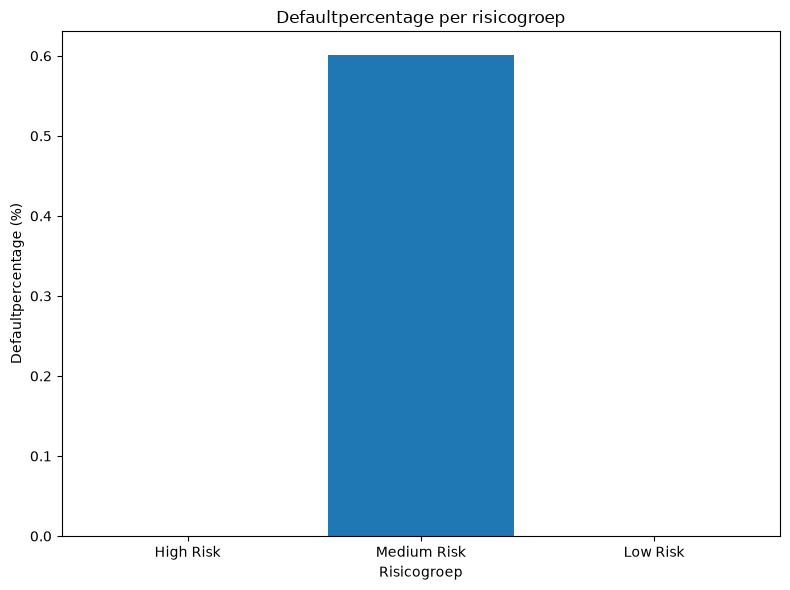

In [131]:
default_by_risk = (
    loans
    .groupby(
        "risk_group",
        observed=False
    )["default_flag"]
    .agg(
        aantal_leningen="count",
        aantal_defaults="sum",
        default_rate="mean"
    )
)
 
default_by_risk["default_rate_pct"] = (
    default_by_risk["default_rate"] * 100
)
 
display(
    default_by_risk[
        [
            "aantal_leningen",
            "aantal_defaults",
            "default_rate_pct"
        ]
    ].round(2)
)
 
plt.figure(figsize=(8, 6))
 
plt.bar(
    default_by_risk.index.astype(str),
    default_by_risk["default_rate_pct"]
)
 
plt.title("Defaultpercentage per risicogroep")
plt.xlabel("Risicogroep")
plt.ylabel("Defaultpercentage (%)")
plt.tight_layout()
 
plt.savefig(
    images_dir / "default_rate_by_risk_group.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()

### 6.6 — Openstaand krediet per risicogroep

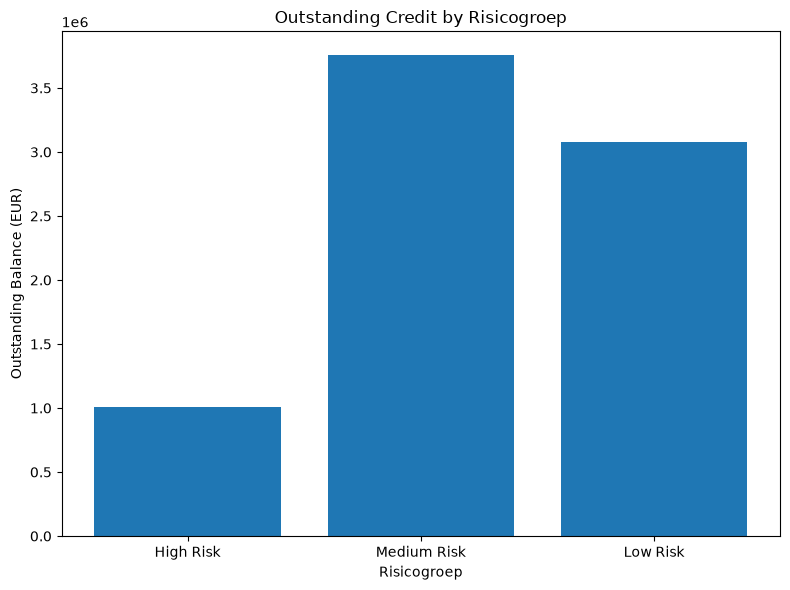

,outstanding_balance_eur
risk_group,
High Risk,1008091.40
Medium Risk,3754698.69
Low Risk,3074558.02


In [132]:
outstanding_by_risk = (
    loans
    .groupby(
        "risk_group",
        observed=False
    )["outstanding_balance_eur"]
    .sum()
)
 
plt.figure(figsize=(8, 6))
 
plt.bar(
    outstanding_by_risk.index.astype(str),
    outstanding_by_risk.values
)
 
plt.title("Outstanding Credit by Risicogroep")
plt.xlabel("Risicogroep")
plt.ylabel("Outstanding Balance (EUR)")
plt.tight_layout()
 
plt.savefig(
    images_dir / "outstanding_credit_by_risk_group.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()
 
display(
    outstanding_by_risk
    .round(2)
    .to_frame("outstanding_balance_eur")
)

### 6.7 — Betalingsachterstand indelen in categorieën

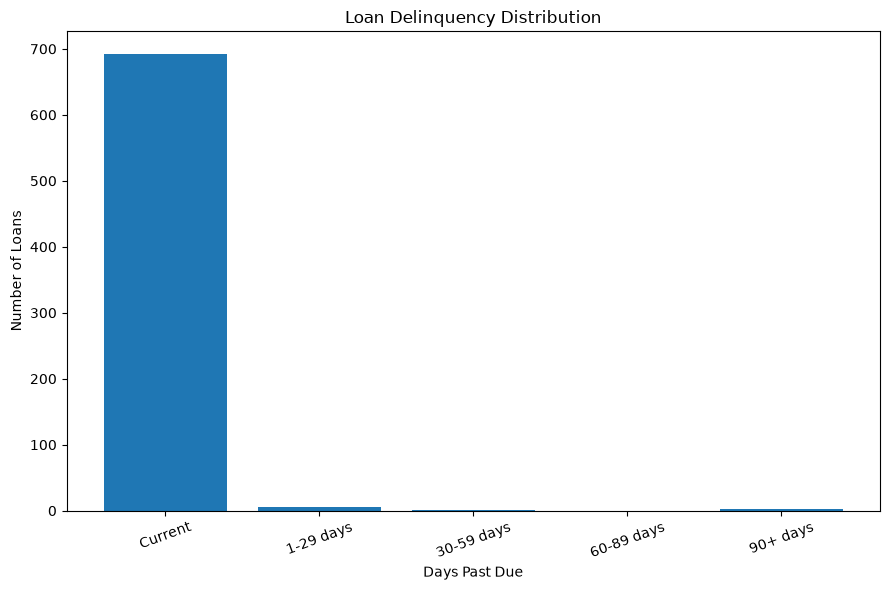

delinquency_group
Current       692
1-29 days       5
30-59 days      1
60-89 days      0
90+ days        2
Name: count, dtype: int64


In [133]:
def delinquency_group(days):
    if days == 0:
        return "Current"
    elif days < 30:
        return "1-29 days"
    elif days < 60:
        return "30-59 days"
    elif days < 90:
        return "60-89 days"
    else:
        return "90+ days"
 
 
loans["delinquency_group"] = (
    loans["days_past_due"]
    .apply(delinquency_group)
)
 
delinquency_order = [
    "Current",
    "1-29 days",
    "30-59 days",
    "60-89 days",
    "90+ days"
]
 
delinquency_counts = (
    loans["delinquency_group"]
    .value_counts()
    .reindex(
        delinquency_order,
        fill_value=0
    )
)
 
plt.figure(figsize=(9, 6))
 
plt.bar(
    delinquency_counts.index,
    delinquency_counts.values
)
 
plt.title("Loan Delinquency Distribution")
plt.xlabel("Days Past Due")
plt.ylabel("Number of Loans")
plt.xticks(rotation=20)
plt.tight_layout()
 
plt.savefig(
    images_dir / "loan_delinquency_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()
 
print(delinquency_counts)

### 6.8 — Risico score vs openstaand krediet

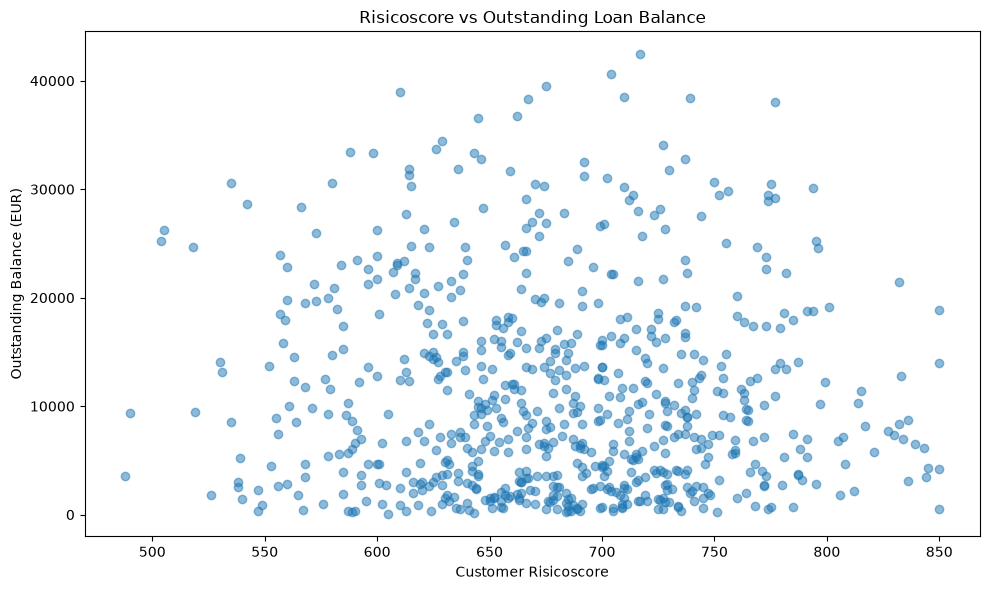

In [134]:
plt.figure(figsize=(10, 6))
 
plt.scatter(
    loans["customer_risk_score"],
    loans["outstanding_balance_eur"],
    alpha=0.5
)
 
plt.title("Risicoscore vs Outstanding Loan Balance")
plt.xlabel("Customer Risicoscore")
plt.ylabel("Outstanding Balance (EUR)")
plt.tight_layout()
 
plt.savefig(
    images_dir / "risk_score_vs_outstanding_balance.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()

### 6.9 — Loans koppelen aan klantsegmenten

In [135]:
loan_customer = loans.merge(
    customers[
        [
            "customer_id",
            "segment",
            "annual_income_eur"
        ]
    ],
    on="customer_id",
    how="left"
)
 
display(
    loan_customer.head()
)

,loan_id,customer_id,origination_date,original_principal_eur,interest_rate_pct,term_months,monthly_payment_eur,outstanding_balance_eur,days_past_due,loan_status,default_flag,customer_risk_score,risk_group,delinquency_group,segment,annual_income_eur
0,1.0,C01277,2026-04-10,36200,8.09,48,885.280029,33719.628906,0,Current,0,626,Medium Risk,Current,Senior,58400
1,2.0,C00918,2025-07-22,21000,9.37,48,526.280029,15653.919922,0,Current,0,699,Medium Risk,Current,Affluent,72400
2,3.0,C02323,2026-03-03,14000,9.84,72,258.230011,13138.870117,0,Current,0,531,High Risk,Current,Young Professional,45500
3,4.0,C02194,2022-08-20,14300,3.71,36,420.350006,2391.870117,0,Current,0,731,Low Risk,Current,Family,46400
4,5.0,C00787,2023-11-19,2700,6.15,48,63.599998,820.469971,0,Current,0,768,Low Risk,Current,Family,48400


### 6.10 — Default rate per klantsegment

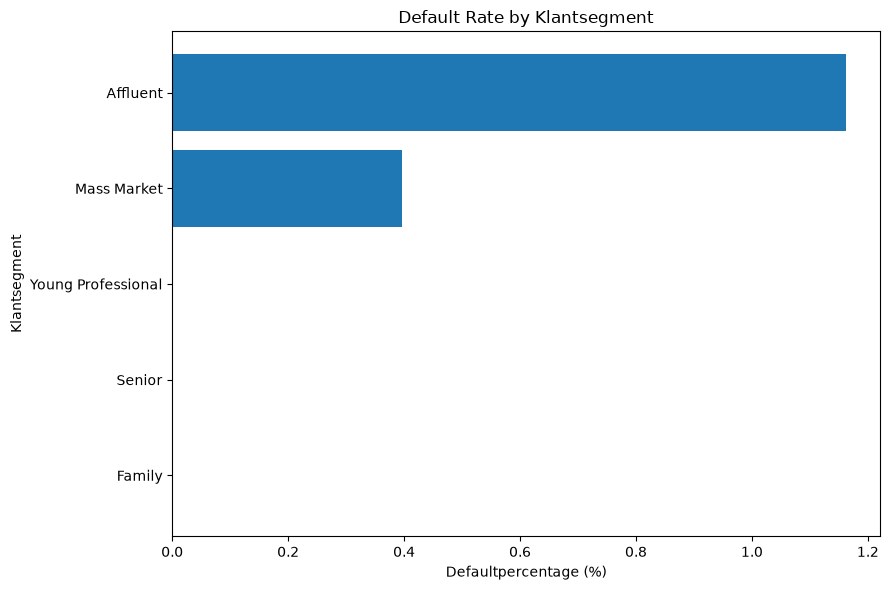

,aantal_leningen,aantal_defaults,default_rate_pct
segment,,,
Family,175,0,0.00
Senior,61,0,0.00
Young Professional,126,0,0.00
Mass Market,252,1,0.40
Affluent,86,1,1.16


In [136]:
segment_default = (
    loan_customer
    .groupby("segment")
    .agg(
        aantal_leningen=("loan_id", "count"),
        aantal_defaults=("default_flag", "sum"),
        default_rate=("default_flag", "mean")
    )
)
 
segment_default["default_rate_pct"] = (
    segment_default["default_rate"] * 100
)
 
segment_default = (
    segment_default
    .sort_values(
        "default_rate_pct",
        ascending=True
    )
)
 
plt.figure(figsize=(9, 6))
 
plt.barh(
    segment_default.index,
    segment_default["default_rate_pct"]
)
 
plt.title("Default Rate by Klantsegment")
plt.xlabel("Defaultpercentage (%)")
plt.ylabel("Klantsegment")
plt.tight_layout()
 
plt.savefig(
    images_dir / "default_rate_by_customer_segment.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()
 
display(
    segment_default[
        [
            "aantal_leningen",
            "aantal_defaults",
            "default_rate_pct"
        ]
    ].round(2)
)

### 6.11 — Debt-to-income ratio per klant berekenen

In [137]:
customer_debt = (
    loans
    .groupby("customer_id")
    .agg(
        aantal_leningen=("loan_id", "count"),
        totaal_openstaand_krediet_eur=(
            "outstanding_balance_eur",
            "sum"
        ),
        max_days_past_due=(
            "days_past_due",
            "max"
        ),
        aantal_defaults=(
            "default_flag",
            "sum"
        )
    )
    .reset_index()
)
 
customer_debt = customer_debt.merge(
    customers[
        [
            "customer_id",
            "segment",
            "annual_income_eur",
            "risk_score"
        ]
    ],
    on="customer_id",
    how="left"
)
 
customer_debt["debt_to_income_pct"] = (
    100
    * customer_debt["totaal_openstaand_krediet_eur"]
    / customer_debt["annual_income_eur"]
)
 
display(
    customer_debt
    .sort_values(
        "debt_to_income_pct",
        ascending=False
    )
    .head(20)
)

,customer_id,aantal_leningen,totaal_openstaand_krediet_eur,max_days_past_due,aantal_defaults,segment,annual_income_eur,risk_score,debt_to_income_pct
596,C02136,1,36756.601562,0,0,Family,50600,662,72.641505
348,C01244,1,19958.449219,0,0,Mass Market,28300,578,70.524556
678,C02431,1,31803.859375,0,0,Young Professional,45500,730,69.898592
404,C01456,1,29804.480469,0,0,Young Professional,42700,756,69.799720
345,C01230,1,36568.089844,0,0,Family,52900,645,69.126824
481,C01707,1,30606.410156,0,0,Mass Market,44500,535,68.778450
139,C00492,1,38030.519531,0,0,Mass Market,55400,777,68.647147
522,C01870,1,26966.720703,0,0,Young Professional,39400,634,68.443454
623,C02256,1,32487.919922,0,0,Family,47900,692,67.824467
146,C00517,1,39554.679688,0,0,Family,58400,675,67.730616


### 6.12 — Gemiddelde debt-to-income ratio per risicogroep

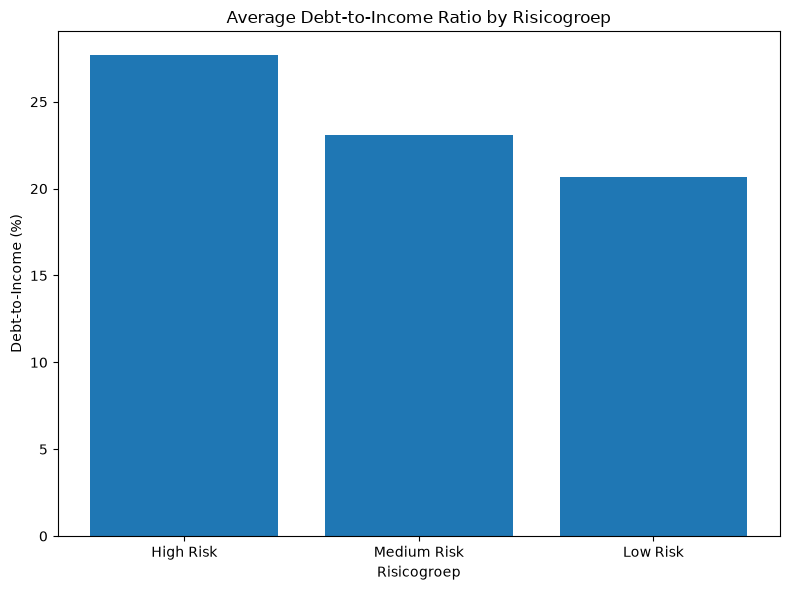

,avg_debt_to_income_pct
risk_group,
High Risk,27.67
Medium Risk,23.06
Low Risk,20.67


In [138]:
customer_debt["risk_group"] = pd.cut(
    customer_debt["risk_score"],
    bins=[
        -float("inf"),
        600,
        700,
        float("inf")
    ],
    labels=[
        "High Risk",
        "Medium Risk",
        "Low Risk"
    ],
    right=False
)
 
dti_by_risk = (
    customer_debt
    .groupby(
        "risk_group",
        observed=False
    )["debt_to_income_pct"]
    .mean()
)
 
plt.figure(figsize=(8, 6))
 
plt.bar(
    dti_by_risk.index.astype(str),
    dti_by_risk.values
)
 
plt.title("Average Debt-to-Income Ratio by Risicogroep")
plt.xlabel("Risicogroep")
plt.ylabel("Debt-to-Income (%)")
plt.tight_layout()
 
plt.savefig(
    images_dir / "debt_to_income_by_risk_group.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()
 
display(
    dti_by_risk
    .round(2)
    .to_frame("avg_debt_to_income_pct")
)

### 6.13 — High-risk klanten met openstaand krediet

In [139]:
high_risk_customers = (
    customer_debt[
        (customer_debt["risk_score"] < 600)
&
        (customer_debt["totaal_openstaand_krediet_eur"] > 0)
    ]
    .sort_values(
        [
            "aantal_defaults",
            "max_days_past_due",
            "totaal_openstaand_krediet_eur"
        ],
        ascending=[
            False,
            False,
            False
        ]
    )
)
 
display(
    high_risk_customers.head(20)
)

,customer_id,aantal_leningen,totaal_openstaand_krediet_eur,max_days_past_due,aantal_defaults,segment,annual_income_eur,risk_score,debt_to_income_pct,risk_group
567,C02037,1,8527.200195,15,0,Young Professional,33100,564,25.761934,High Risk
162,C00574,1,6984.919922,15,0,Mass Market,59900,593,11.660968,High Risk
368,C01304,1,2658.949951,15,0,Family,30100,556,8.833721,High Risk
491,C01743,1,33438.648438,0,0,Affluent,58300,588,57.356172,High Risk
620,C02251,1,33325.281250,0,0,Senior,62500,598,53.320450,High Risk
481,C01707,1,30606.410156,0,0,Mass Market,44500,535,68.778450,High Risk
95,C00342,1,30562.160156,0,0,Mass Market,60400,580,50.599603,High Risk
578,C02070,1,28641.869141,0,0,Mass Market,47200,542,60.681926,High Risk
155,C00553,1,28348.560547,0,0,Mass Market,52100,566,54.411824,High Risk
472,C01685,1,26200.910156,0,0,Mass Market,50200,505,52.193048,High Risk


### 6.14 — Samenvatting belangrijkste credit risk KPI's

In [140]:
credit_risk_summary = pd.Series(
    {
        "Total Loans":
            len(loans),
 
        "Original Principal EUR":
            loans["original_principal_eur"].sum(),
 
        "Outstanding Balance EUR":
            loans["outstanding_balance_eur"].sum(),
 
        "Average Interest Rate %":
            loans["interest_rate_pct"].mean(),
 
        "Customers in Default":
            loans.loc[
                loans["default_flag"] == 1,
                "customer_id"
            ].nunique(),
 
        "Defaulted Loans":
            loans["default_flag"].sum(),
 
        "Overall Default Rate %":
            loans["default_flag"].mean() * 100,
 
        "Loans Past Due":
            (loans["days_past_due"] > 0).sum(),
 
        "90+ Days Past Due":
            (loans["days_past_due"] >= 90).sum(),
 
        "Average Risicoscore":
            loans["customer_risk_score"].mean()
    }
)
 
display(
    credit_risk_summary
    .round(2)
    .to_frame("Value")
)

,Value
Total Loans,700.00
Original Principal EUR,13070500.00
Outstanding Balance EUR,7837348.11
Average Interest Rate %,7.23
Customers in Default,2.00
Defaulted Loans,2.00
Overall Default Rate %,0.29
Loans Past Due,8.00
90+ Days Past Due,2.00
Average Risicoscore,680.76


## 7 — Analyse van Verdachte Transacties

> **Interpretatienota:** `is_suspicious` is a synthetische analytische indicator. A flagged transaction should not be interpreted as bevestigde fraude.

In [141]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
 
project_root = Path.cwd()
if project_root.name.lower() == "notebooks":
    project_root = project_root.parent

images_dir = project_root / "Images"
images_dir.mkdir(parents=True, exist_ok=True)

### 7.1 — Verdacht kolom voorbereiden

In [142]:
transactions["is_suspicious"] = (
    transactions["is_suspicious"]
    .astype(int)
)
 
transactions["is_international"] = (
    transactions["is_international"]
    .astype(int)
)
 
transactions["suspicious_label"] = transactions["is_suspicious"].map(
    {
        0: "Not Suspicious",
        1: "Suspicious"
    }
)
 
print("Aantal suspicious transacties:")
print(transactions["is_suspicious"].sum())
 
print("\nSuspicious rate (%):")
print(
    round(
        transactions["is_suspicious"].mean() * 100,
        2
    )
)

Aantal suspicious transacties:
65

Suspicious rate (%):
0.65


### 7.2 — Verdacht vs non-suspicious transacties

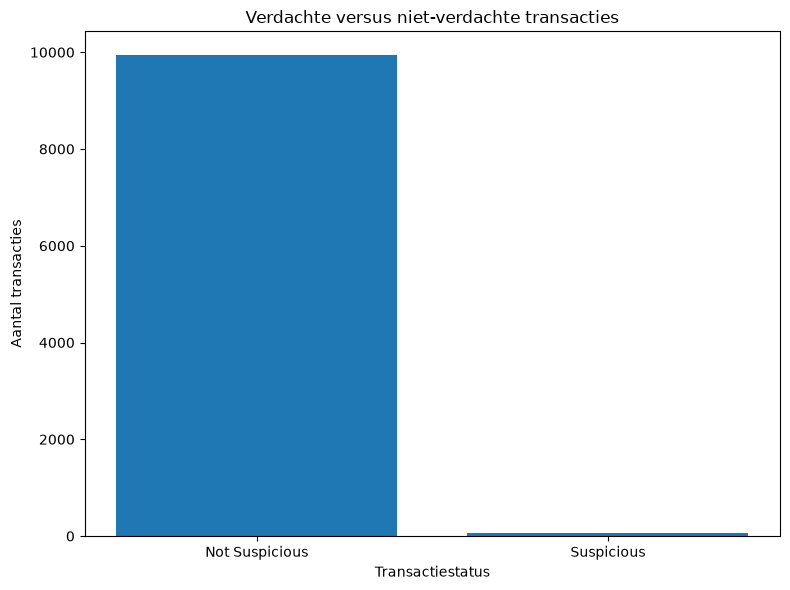

In [143]:
suspicious_counts = (
    transactions["suspicious_label"]
    .value_counts()
)
 
plt.figure(figsize=(8, 6))
 
plt.bar(
    suspicious_counts.index,
    suspicious_counts.values
)
 
plt.title("Verdachte versus niet-verdachte transacties")
plt.xlabel("Transactiestatus")
plt.ylabel("Aantal transacties")
plt.tight_layout()
 
plt.savefig(
    images_dir / "suspicious_vs_non_suspicious.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()

### 7.3 — Verdacht rate: domestic versus international

,aantal_transacties,suspicious_transacties,suspicious_rate_pct
transaction_scope,,,
Domestic,9809,59,0.60
International,191,6,3.14


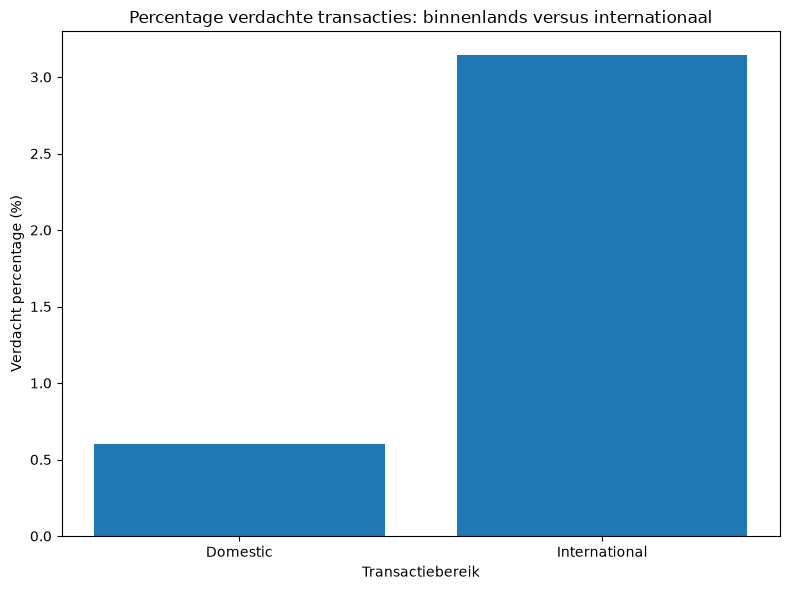

In [144]:
scope_summary = (
    transactions
    .assign(
        transaction_scope=transactions["is_international"].map(
            {
                0: "Domestic",
                1: "International"
            }
        )
    )
    .groupby("transaction_scope")
    .agg(
        aantal_transacties=("transaction_id", "count"),
        suspicious_transacties=("is_suspicious", "sum"),
        suspicious_rate=("is_suspicious", "mean")
    )
)
 
scope_summary["suspicious_rate_pct"] = (
    scope_summary["suspicious_rate"] * 100
)
 
display(
    scope_summary[
        [
            "aantal_transacties",
            "suspicious_transacties",
            "suspicious_rate_pct"
        ]
    ].round(2)
)
 
plt.figure(figsize=(8, 6))
 
plt.bar(
    scope_summary.index,
    scope_summary["suspicious_rate_pct"]
)
 
plt.title("Percentage verdachte transacties: binnenlands versus internationaal")
plt.xlabel("Transactiebereik")
plt.ylabel("Verdacht percentage (%)")
plt.tight_layout()
 
plt.savefig(
    images_dir / "suspicious_rate_domestic_vs_international.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()

### 7.4 — Verdacht rate per kanaal

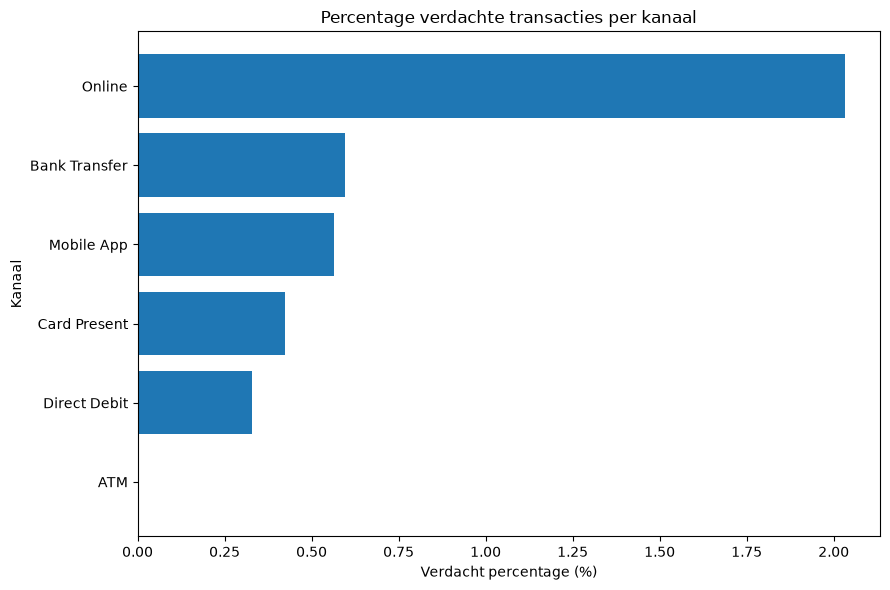

,aantal_transacties,suspicious_transacties,suspicious_rate_pct
channel,,,
ATM,451,0,0.00
Direct Debit,1217,4,0.33
Card Present,1893,8,0.42
Mobile App,2839,16,0.56
Bank Transfer,2517,15,0.60
Online,1083,22,2.03


In [145]:
channel_summary = (
    transactions
    .groupby("channel")
    .agg(
        aantal_transacties=("transaction_id", "count"),
        suspicious_transacties=("is_suspicious", "sum"),
        suspicious_rate=("is_suspicious", "mean")
    )
)
 
channel_summary["suspicious_rate_pct"] = (
    channel_summary["suspicious_rate"] * 100
)
 
channel_summary = (
    channel_summary
    .sort_values(
        "suspicious_rate_pct",
        ascending=True
    )
)
 
plt.figure(figsize=(9, 6))
 
plt.barh(
    channel_summary.index,
    channel_summary["suspicious_rate_pct"]
)
 
plt.title("Percentage verdachte transacties per kanaal")
plt.xlabel("Verdacht percentage (%)")
plt.ylabel("Kanaal")
plt.tight_layout()
 
plt.savefig(
    images_dir / "suspicious_rate_by_channel.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()
 
display(
    channel_summary[
        [
            "aantal_transacties",
            "suspicious_transacties",
            "suspicious_rate_pct"
        ]
    ].round(2)
)

### 7.5 — Verdacht rate per categorie

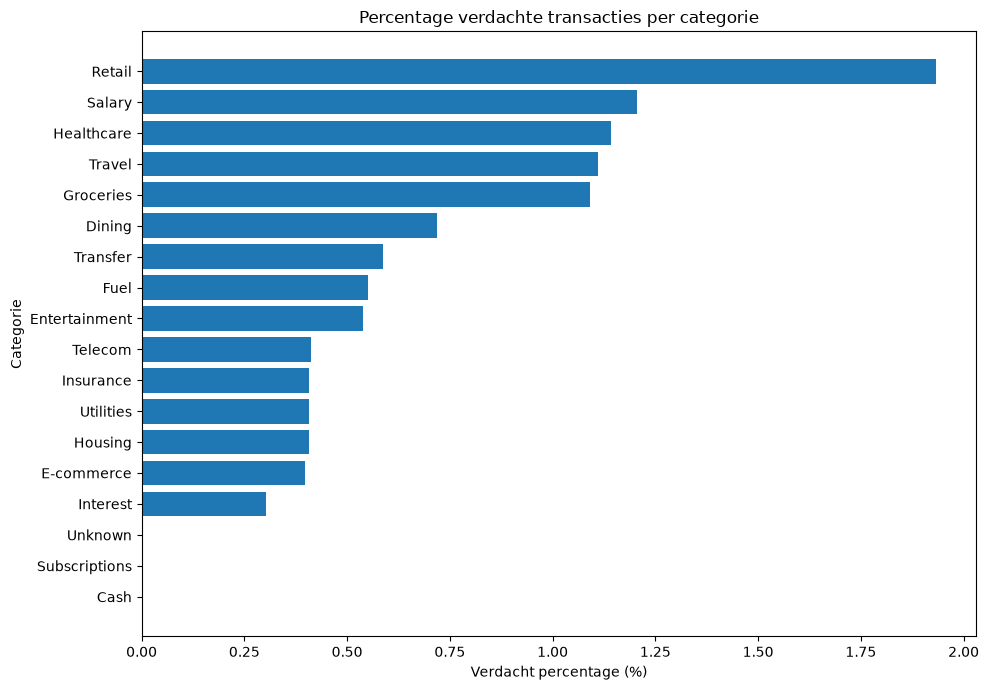

,aantal_transacties,suspicious_transacties,suspicious_rate_pct
category,,,
Cash,451,0,0.00
Subscriptions,240,0,0.00
Unknown,57,0,0.00
Interest,331,1,0.30
E-commerce,503,2,0.40
Housing,245,1,0.41
Utilities,245,1,0.41
Insurance,245,1,0.41
Telecom,242,1,0.41


In [146]:
category_summary = (
    transactions
    .groupby("category")
    .agg(
        aantal_transacties=("transaction_id", "count"),
        suspicious_transacties=("is_suspicious", "sum"),
        suspicious_rate=("is_suspicious", "mean")
    )
)
 
category_summary["suspicious_rate_pct"] = (
    category_summary["suspicious_rate"] * 100
)
 
# Kleine categorieën uitsluiten voor stabielere vergelijking
category_summary_filtered = (
    category_summary[
        category_summary["aantal_transacties"] >= 50
    ]
    .sort_values(
        "suspicious_rate_pct",
        ascending=True
    )
)
 
plt.figure(figsize=(10, 7))
 
plt.barh(
    category_summary_filtered.index,
    category_summary_filtered["suspicious_rate_pct"]
)
 
plt.title("Percentage verdachte transacties per categorie")
plt.xlabel("Verdacht percentage (%)")
plt.ylabel("Categorie")
plt.tight_layout()
 
plt.savefig(
    images_dir / "suspicious_rate_by_category.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()
 
display(
    category_summary_filtered[
        [
            "aantal_transacties",
            "suspicious_transacties",
            "suspicious_rate_pct"
        ]
    ].round(2)
)

### 7.6 — Transactiewaarde: suspicious vs non-suspicious

In [147]:
amount_summary = (
    transactions
    .groupby("suspicious_label")
    .agg(
        aantal_transacties=("transaction_id", "count"),
        gemiddeld_bedrag_eur=("abs_amount_eur", "mean"),
        mediaan_bedrag_eur=("abs_amount_eur", "median"),
        maximum_bedrag_eur=("abs_amount_eur", "max")
    )
)
 
display(
    amount_summary.round(2)
)

,aantal_transacties,gemiddeld_bedrag_eur,mediaan_bedrag_eur,maximum_bedrag_eur
suspicious_label,,,,
Not Suspicious,9935,401.03,150.00,10111.77
Suspicious,65,656.86,162.49,9961.00


### 7.7 — Boxplot transactiewaarde per suspicious status

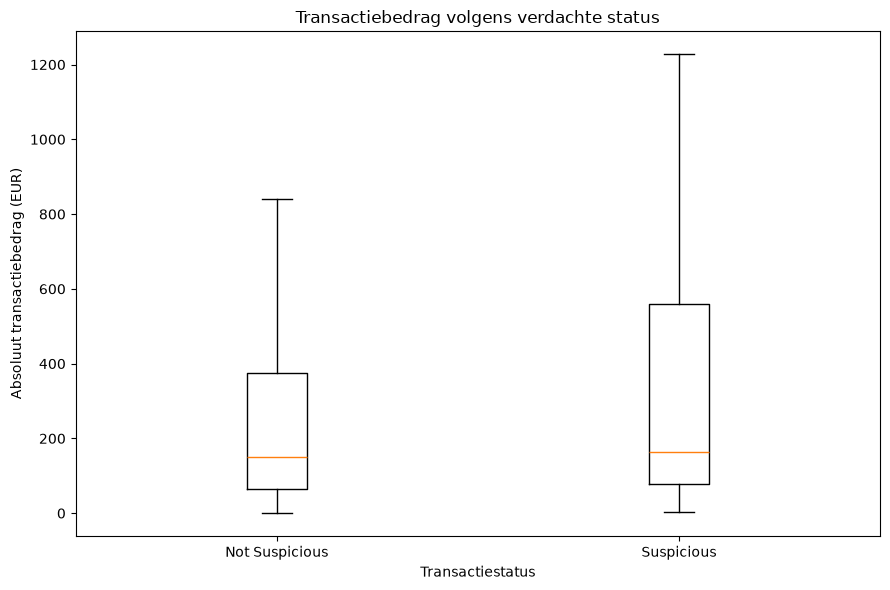

In [148]:
not_suspicious_amounts = transactions.loc[
    transactions["is_suspicious"] == 0,
    "abs_amount_eur"
]
 
suspicious_amounts = transactions.loc[
    transactions["is_suspicious"] == 1,
    "abs_amount_eur"
]
 
plt.figure(figsize=(9, 6))
 
plt.boxplot(
    [
        not_suspicious_amounts,
        suspicious_amounts
    ],
    tick_labels=[
        "Not Suspicious",
        "Suspicious"
    ],
    showfliers=False
)
 
plt.title("Transactiebedrag volgens verdachte status")
plt.xlabel("Transactiestatus")
plt.ylabel("Absoluut transactiebedrag (EUR)")
plt.tight_layout()
 
plt.savefig(
    images_dir / "transaction_amount_by_suspicious_status.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()

### 7.8 — Verdacht rate per klantsegment

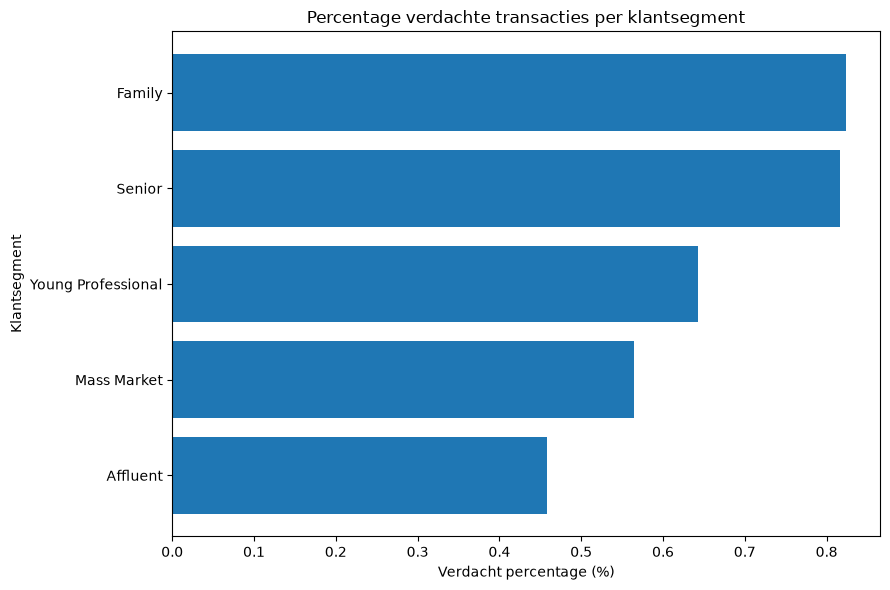

,aantal_transacties,suspicious_transacties,suspicious_rate_pct
segment,,,
Affluent,1309,6,0.46
Mass Market,3539,20,0.57
Young Professional,1868,12,0.64
Senior,857,7,0.82
Family,2427,20,0.82


In [149]:
transaction_customer = transactions.merge(
    customers[
        [
            "customer_id",
            "segment",
            "risk_score",
            "annual_income_eur"
        ]
    ],
    on="customer_id",
    how="left"
)
 
segment_suspicious = (
    transaction_customer
    .groupby("segment")
    .agg(
        aantal_transacties=("transaction_id", "count"),
        suspicious_transacties=("is_suspicious", "sum"),
        suspicious_rate=("is_suspicious", "mean")
    )
)
 
segment_suspicious["suspicious_rate_pct"] = (
    segment_suspicious["suspicious_rate"] * 100
)
 
segment_suspicious = (
    segment_suspicious
    .sort_values(
        "suspicious_rate_pct",
        ascending=True
    )
)
 
plt.figure(figsize=(9, 6))
 
plt.barh(
    segment_suspicious.index,
    segment_suspicious["suspicious_rate_pct"]
)
 
plt.title("Percentage verdachte transacties per klantsegment")
plt.xlabel("Verdacht percentage (%)")
plt.ylabel("Klantsegment")
plt.tight_layout()
 
plt.savefig(
    images_dir / "suspicious_rate_by_customer_segment.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()
 
display(
    segment_suspicious[
        [
            "aantal_transacties",
            "suspicious_transacties",
            "suspicious_rate_pct"
        ]
    ].round(2)
)

### 7.9 — Verdacht rate per risicogroep

,aantal_transacties,suspicious_transacties,suspicious_rate_pct
risk_group,,,
High Risk,1092,10,0.92
Medium Risk,4754,35,0.74
Low Risk,4154,20,0.48


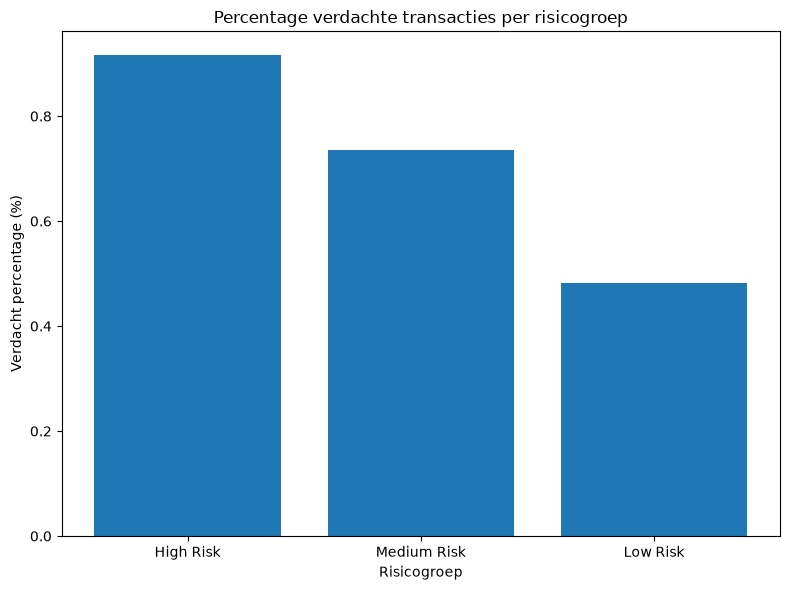

In [150]:
transaction_customer["risk_group"] = pd.cut(
    transaction_customer["risk_score"],
    bins=[
        -float("inf"),
        600,
        700,
        float("inf")
    ],
    labels=[
        "High Risk",
        "Medium Risk",
        "Low Risk"
    ],
    right=False
)
 
risk_suspicious = (
    transaction_customer
    .groupby(
        "risk_group",
        observed=False
    )
    .agg(
        aantal_transacties=("transaction_id", "count"),
        suspicious_transacties=("is_suspicious", "sum"),
        suspicious_rate=("is_suspicious", "mean")
    )
)
 
risk_suspicious["suspicious_rate_pct"] = (
    risk_suspicious["suspicious_rate"] * 100
)
 
display(
    risk_suspicious[
        [
            "aantal_transacties",
            "suspicious_transacties",
            "suspicious_rate_pct"
        ]
    ].round(2)
)
 
plt.figure(figsize=(8, 6))
 
plt.bar(
    risk_suspicious.index.astype(str),
    risk_suspicious["suspicious_rate_pct"]
)
 
plt.title("Percentage verdachte transacties per risicogroep")
plt.xlabel("Risicogroep")
plt.ylabel("Verdacht percentage (%)")
plt.tight_layout()
 
plt.savefig(
    images_dir / "suspicious_rate_by_risk_group.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()

### 7.10 — Kanaal + international/domestic combineren

In [151]:
transaction_customer["transaction_scope"] = (
    transaction_customer["is_international"]
    .map(
        {
            0: "Domestic",
            1: "International"
        }
    )
)
 
channel_scope = (
    transaction_customer
    .groupby(
        [
            "channel",
            "transaction_scope"
        ]
    )
    .agg(
        aantal_transacties=("transaction_id", "count"),
        suspicious_transacties=("is_suspicious", "sum"),
        suspicious_rate=("is_suspicious", "mean")
    )
    .reset_index()
)
 
channel_scope["suspicious_rate_pct"] = (
    channel_scope["suspicious_rate"] * 100
)
 
channel_scope = (
    channel_scope[
        channel_scope["aantal_transacties"] >= 20
    ]
    .sort_values(
        "suspicious_rate_pct",
        ascending=False
    )
)
 
display(
    channel_scope[
        [
            "channel",
            "transaction_scope",
            "aantal_transacties",
            "suspicious_transacties",
            "suspicious_rate_pct"
        ]
    ].round(2)
)

,channel,transaction_scope,aantal_transacties,suspicious_transacties,suspicious_rate_pct
8,Online,International,57,4,7.02
7,Online,Domestic,1026,18,1.75
3,Card Present,International,115,2,1.74
1,Bank Transfer,Domestic,2517,15,0.60
5,Mobile App,Domestic,2820,16,0.57
2,Card Present,Domestic,1778,6,0.34
4,Direct Debit,Domestic,1217,4,0.33
0,ATM,Domestic,451,0,0.00


### 7.11 — Top 20 grootste suspicious transactions

In [152]:
top_suspicious = (
    transaction_customer[
        transaction_customer["is_suspicious"] == 1
    ]
    .sort_values(
        "abs_amount_eur",
        ascending=False
    )
    [
        [
            "transaction_id",
            "customer_id",
            "segment",
            "risk_score",
            "transaction_datetime",
            "transaction_type",
            "category",
            "amount_eur",
            "abs_amount_eur",
            "merchant_country",
            "channel",
            "is_international"
        ]
    ]
    .head(20)
)
 
display(top_suspicious)

,transaction_id,customer_id,segment,risk_score,transaction_datetime,transaction_type,category,amount_eur,abs_amount_eur,merchant_country,channel,is_international
2210,T0002211,C01393,Affluent,708,2026-02-28 02:33:02,Salary,Salary,9961.000000,9961.000000,Luxembourg,Mobile App,0
3477,T0003478,C01607,Senior,678,2024-09-18 06:43:16,Salary,Salary,4722.600098,4722.600098,France,Bank Transfer,0
4638,T0004639,C01812,Young Professional,804,2026-05-31 19:20:37,Salary,Salary,3276.010010,3276.010010,Netherlands,Mobile App,0
4745,T0004746,C01329,Family,668,2025-11-03 09:09:09,Salary,Salary,3078.899902,3078.899902,Belgium,Bank Transfer,0
672,T0000673,C01457,Mass Market,538,2025-09-13 03:49:24,Salary,Salary,1815.810059,1815.810059,Belgium,Bank Transfer,0
4041,T0004042,C01587,Senior,664,2026-07-27 15:15:57,Card Purchase,Travel,-1339.510010,1339.510010,Germany,Online,1
5789,T0005790,C00574,Mass Market,593,2025-04-10 21:14:59,Transfer Out,Transfer,-1227.489990,1227.489990,France,Bank Transfer,0
9193,T0009194,C00404,Mass Market,638,2024-06-03 09:56:35,Transfer In,Transfer,1193.020020,1193.020020,Belgium,Mobile App,0
2187,T0002188,C02234,Family,630,2024-01-28 18:26:03,Transfer In,Transfer,1188.459961,1188.459961,Belgium,Bank Transfer,0
2157,T0002158,C00681,Young Professional,538,2024-08-31 23:06:22,Transfer In,Transfer,1120.459961,1120.459961,Netherlands,Mobile App,0


### 7.12 — Verdacht transacties per maand

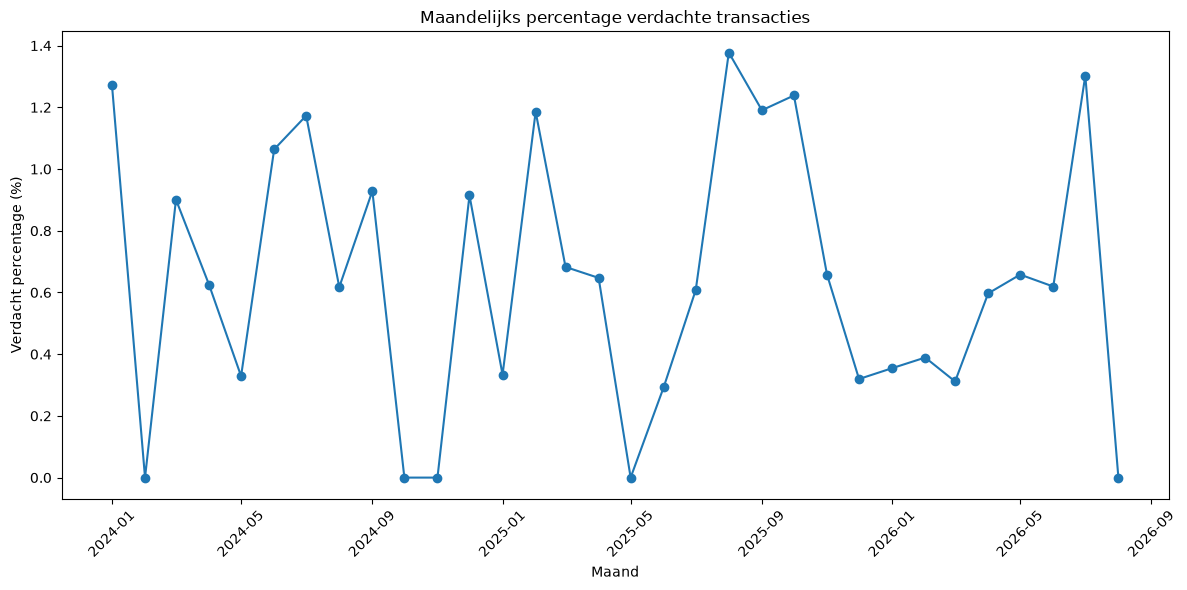

In [153]:
monthly_suspicious = (
    transactions
    .set_index("transaction_datetime")
    .resample("MS")
    .agg(
        aantal_transacties=("transaction_id", "count"),
        suspicious_transacties=("is_suspicious", "sum"),
        suspicious_rate=("is_suspicious", "mean")
    )
)
 
monthly_suspicious["suspicious_rate_pct"] = (
    monthly_suspicious["suspicious_rate"] * 100
)
 
plt.figure(figsize=(12, 6))
 
plt.plot(
    monthly_suspicious.index,
    monthly_suspicious["suspicious_rate_pct"],
    marker="o"
)
 
plt.title("Maandelijks percentage verdachte transacties")
plt.xlabel("Maand")
plt.ylabel("Verdacht percentage (%)")
plt.xticks(rotation=45)
plt.tight_layout()
 
plt.savefig(
    images_dir / "monthly_suspicious_rate.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()

### 7.13 — Samenvatting belangrijkste suspicious transaction KPI's

In [154]:
suspicious_summary = pd.Series(
    {
        "Total Transactions":
            len(transactions),
 
        "Suspicious Transactions":
            transactions["is_suspicious"].sum(),
 
        "Suspicious Rate %":
            transactions["is_suspicious"].mean() * 100,
 
        "International Transactions":
            transactions["is_international"].sum(),
 
        "International Rate %":
            transactions["is_international"].mean() * 100,
 
        "Average Transaction EUR":
            transactions["abs_amount_eur"].mean(),
 
        "Average Suspicious Transaction EUR":
            transactions.loc[
                transactions["is_suspicious"] == 1,
                "abs_amount_eur"
            ].mean(),
 
        "Largest Suspicious Transaction EUR":
            transactions.loc[
                transactions["is_suspicious"] == 1,
                "abs_amount_eur"
            ].max()
    }
)
 
display(
    suspicious_summary
    .round(2)
    .to_frame("Value")
)

,Value
Total Transactions,10000.00
Suspicious Transactions,65.00
Suspicious Rate %,0.65
International Transactions,191.00
International Rate %,1.91
Average Transaction EUR,402.70
Average Suspicious Transaction EUR,656.86
Largest Suspicious Transaction EUR,9961.00


## 8 — Correlaties & Verdiepende Analyse

### 8.1 — Numerieke variabelen selecteren voor correlatieanalyse

In [155]:
correlation_columns = [
    "annual_income_eur",
    "risk_score",
    "aantal_accounts",
    "aantal_leningen",
    "openstaand_krediet_eur",
    "max_days_past_due",
    "aantal_defaults",
    "aantal_transacties",
    "netto_cashflow_eur",
    "suspicious_transacties"
]
 
customer_corr_data = customers[
    correlation_columns
].copy()
 
display(
    customer_corr_data
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
annual_income_eur,2500.0,53612.360000,21157.668823,16000.00000,39100.000000,51050.000000,64200.000000,165800.000000
risk_score,2500.0,682.376400,67.099780,441.00000,637.000000,683.000000,729.000000,850.000000
aantal_accounts,2500.0,1.635200,0.656577,1.00000,1.000000,2.000000,2.000000,3.000000
aantal_leningen,2500.0,0.280000,0.449089,0.00000,0.000000,0.000000,1.000000,1.000000
openstaand_krediet_eur,2500.0,3134.939246,6987.300863,0.00000,0.000000,0.000000,1480.649994,42438.050781
max_days_past_due,2500.0,0.114000,2.698132,0.00000,0.000000,0.000000,0.000000,90.000000
aantal_defaults,2500.0,0.000800,0.028279,0.00000,0.000000,0.000000,0.000000,1.000000
aantal_transacties,2500.0,4.000000,2.644768,0.00000,2.000000,4.000000,6.000000,16.000000
netto_cashflow_eur,2500.0,444.357444,1804.467023,-6504.25988,-426.972486,-28.049999,725.955000,15212.989686
suspicious_transacties,2500.0,0.026000,0.161662,0.00000,0.000000,0.000000,0.000000,2.000000


### 8.2 — Correlatiematrix berekenen

In [156]:
correlation_matrix = (
    customer_corr_data
    .corr()
)
 
display(
    correlation_matrix.round(2)
)

,annual_income_eur,risk_score,aantal_accounts,aantal_leningen,openstaand_krediet_eur,max_days_past_due,aantal_defaults,aantal_transacties,netto_cashflow_eur,suspicious_transacties
annual_income_eur,1.00,0.26,-0.01,-0.03,0.04,-0.00,-0.01,0.00,0.10,-0.01
risk_score,0.26,1.00,0.00,-0.02,-0.03,-0.03,-0.01,0.01,0.02,-0.04
aantal_accounts,-0.01,0.00,1.00,0.03,0.02,-0.01,-0.01,0.62,0.09,0.07
aantal_leningen,-0.03,-0.02,0.03,1.00,0.72,0.07,0.05,0.02,0.02,0.02
openstaand_krediet_eur,0.04,-0.03,0.02,0.72,1.00,0.04,0.01,0.01,0.05,0.03
max_days_past_due,-0.00,-0.03,-0.01,0.07,0.04,1.00,0.94,0.01,-0.00,0.01
aantal_defaults,-0.01,-0.01,-0.01,0.05,0.01,0.94,1.00,0.01,-0.00,-0.00
aantal_transacties,0.00,0.01,0.62,0.02,0.01,0.01,0.01,1.00,0.17,0.15
netto_cashflow_eur,0.10,0.02,0.09,0.02,0.05,-0.00,-0.00,0.17,1.00,0.04
suspicious_transacties,-0.01,-0.04,0.07,0.02,0.03,0.01,-0.00,0.15,0.04,1.00


### 8.3 — Correlatiematrix visualiseren

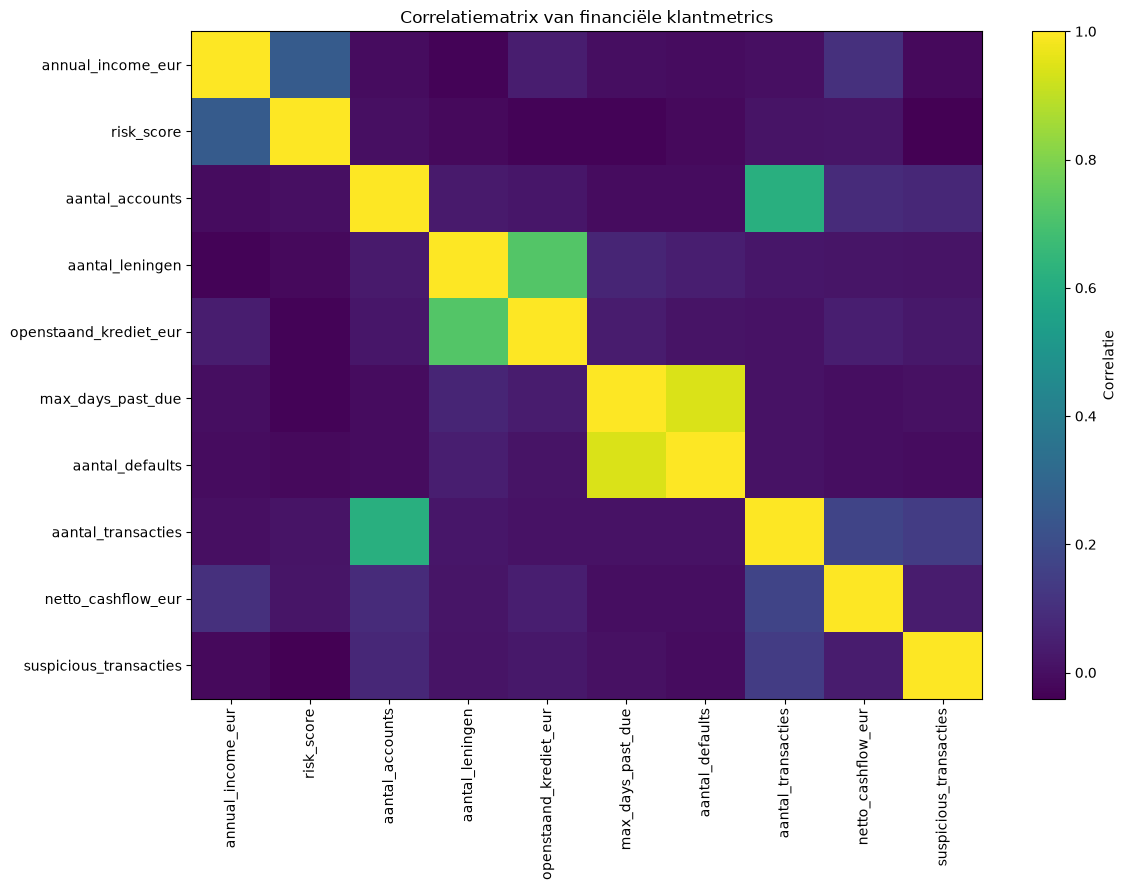

In [157]:
plt.figure(figsize=(12, 9))
 
plt.imshow(
    correlation_matrix,
    aspect="auto"
)
 
plt.colorbar(
    label="Correlatie"
)
 
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)
 
plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)
 
plt.title("Correlatiematrix van financiële klantmetrics")
plt.tight_layout()
 
plt.savefig(
    images_dir / "customer_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()

### 8.4 — Sterkste positieve en negatieve correlaties tonen

In [158]:
correlation_pairs = (
    correlation_matrix
    .where(
        ~pd.DataFrame(
            False,
            index=correlation_matrix.index,
            columns=correlation_matrix.columns
        )
    )
    .stack()
    .reset_index()
)
 
correlation_pairs.columns = [
    "variable_1",
    "variable_2",
    "correlation"
]
 
correlation_pairs = correlation_pairs[
    correlation_pairs["variable_1"]
    != correlation_pairs["variable_2"]
]
 
# Dubbele combinaties verwijderen
correlation_pairs["pair"] = correlation_pairs.apply(
    lambda row: tuple(
        sorted(
            [
                row["variable_1"],
                row["variable_2"]
            ]
        )
    ),
    axis=1
)
 
correlation_pairs = (
    correlation_pairs
    .drop_duplicates("pair")
    .drop(columns="pair")
)
 
correlation_pairs["abs_correlation"] = (
    correlation_pairs["correlation"].abs()
)
 
display(
    correlation_pairs
    .sort_values(
        "abs_correlation",
        ascending=False
    )
    .head(15)
    .round(3)
)

,variable_1,variable_2,correlation,abs_correlation
56,max_days_past_due,aantal_defaults,0.943,0.943
34,aantal_leningen,openstaand_krediet_eur,0.720,0.720
27,aantal_accounts,aantal_transacties,0.616,0.616
1,annual_income_eur,risk_score,0.257,0.257
78,aantal_transacties,netto_cashflow_eur,0.172,0.172
79,aantal_transacties,suspicious_transacties,0.146,0.146
8,annual_income_eur,netto_cashflow_eur,0.102,0.102
28,aantal_accounts,netto_cashflow_eur,0.086,0.086
29,aantal_accounts,suspicious_transacties,0.074,0.074
35,aantal_leningen,max_days_past_due,0.068,0.068


### 8.5 — Inkomen versus risk score

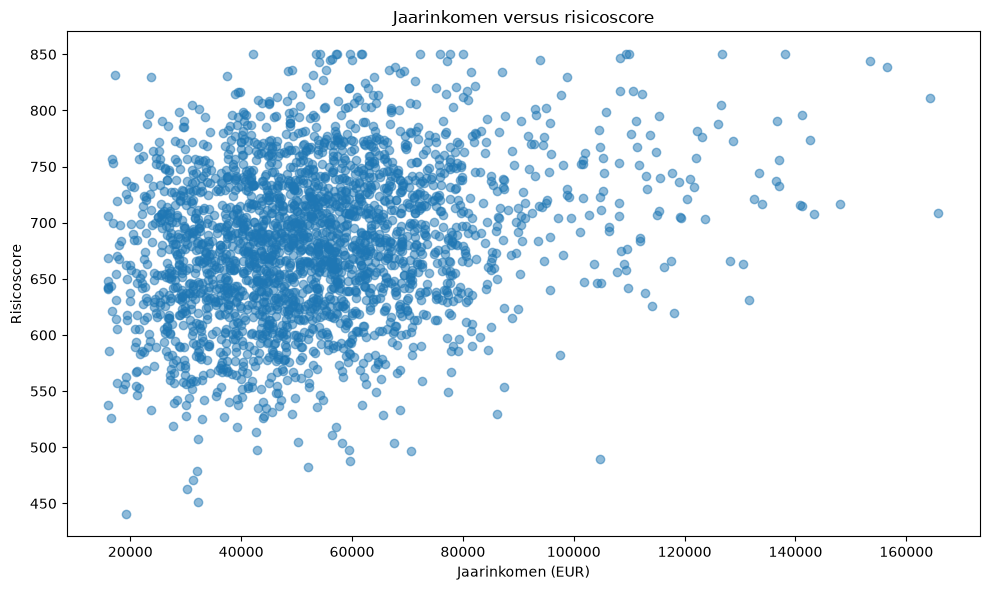

Correlatie income vs risk score: 0.257


In [159]:
plt.figure(figsize=(10, 6))
 
plt.scatter(
    customers["annual_income_eur"],
    customers["risk_score"],
    alpha=0.5
)
 
plt.title("Jaarinkomen versus risicoscore")
plt.xlabel("Jaarinkomen (EUR)")
plt.ylabel("Risicoscore")
plt.tight_layout()
 
plt.savefig(
    images_dir / "income_vs_risk_score.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()
 
print(
    "Correlatie income vs risk score:",
    round(
        customers[
            [
                "annual_income_eur",
                "risk_score"
            ]
        ]
        .corr()
        .iloc[0, 1],
        3
    )
)

### 8.6 — Risico score versus openstaand krediet

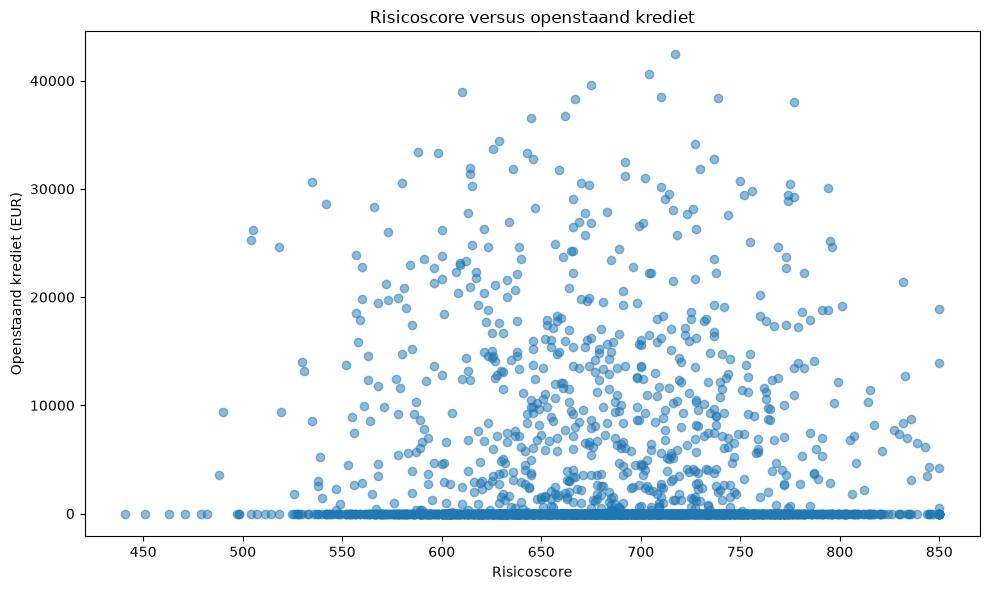

Correlatie risk score vs outstanding credit: -0.032


In [160]:
plt.figure(figsize=(10, 6))
 
plt.scatter(
    customers["risk_score"],
    customers["openstaand_krediet_eur"],
    alpha=0.5
)
 
plt.title("Risicoscore versus openstaand krediet")
plt.xlabel("Risicoscore")
plt.ylabel("Openstaand krediet (EUR)")
plt.tight_layout()
 
plt.savefig(
    images_dir / "risk_score_vs_customer_credit.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()
 
print(
    "Correlatie risk score vs outstanding credit:",
    round(
        customers[
            [
                "risk_score",
                "openstaand_krediet_eur"
            ]
        ]
        .corr()
        .iloc[0, 1],
        3
    )
)

### 8.7 — Inkomen versus openstaand krediet

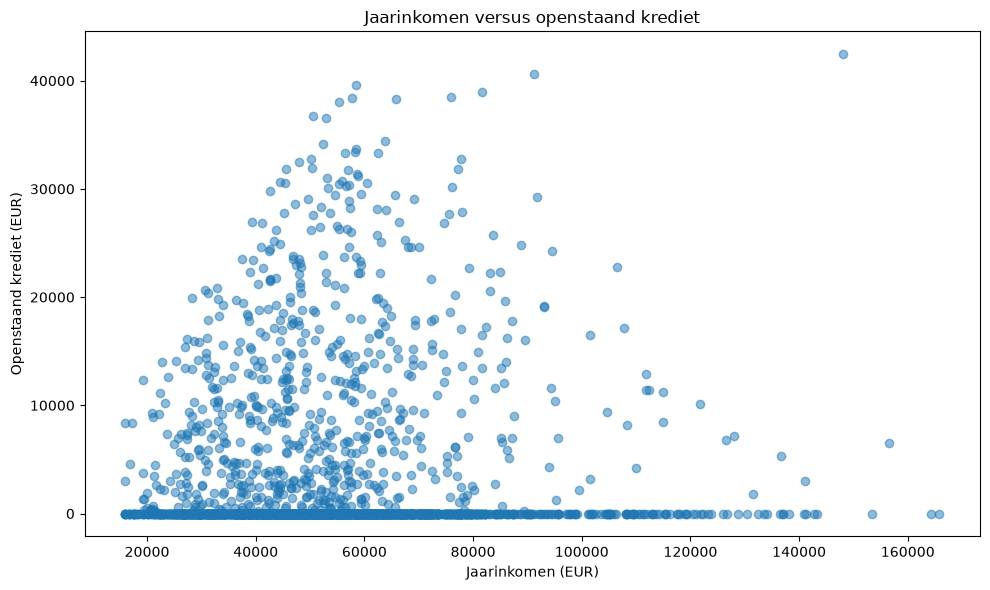

In [161]:
plt.figure(figsize=(10, 6))
 
plt.scatter(
    customers["annual_income_eur"],
    customers["openstaand_krediet_eur"],
    alpha=0.5
)
 
plt.title("Jaarinkomen versus openstaand krediet")
plt.xlabel("Jaarinkomen (EUR)")
plt.ylabel("Openstaand krediet (EUR)")
plt.tight_layout()
 
plt.savefig(
    images_dir / "income_vs_outstanding_credit.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()

### 8.8 — Cashflow versus suspicious transacties

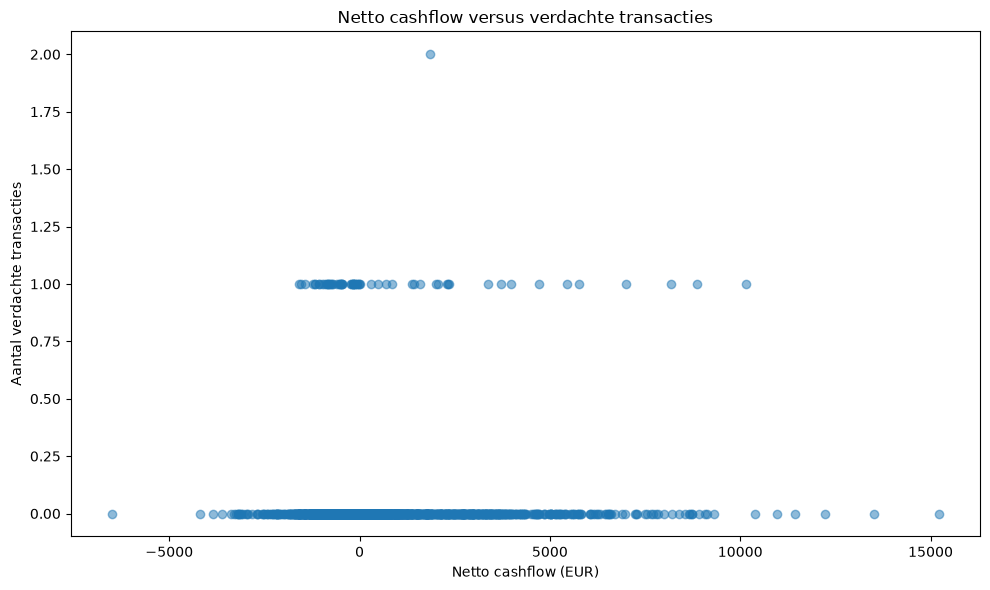

In [162]:
plt.figure(figsize=(10, 6))
 
plt.scatter(
    customers["netto_cashflow_eur"],
    customers["suspicious_transacties"],
    alpha=0.5
)
 
plt.title("Netto cashflow versus verdachte transacties")
plt.xlabel("Netto cashflow (EUR)")
plt.ylabel("Aantal verdachte transacties")
plt.tight_layout()
 
plt.savefig(
    images_dir / "cashflow_vs_suspicious_transactions.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()

### 8.9 — Betalingsachterstand versus risk score

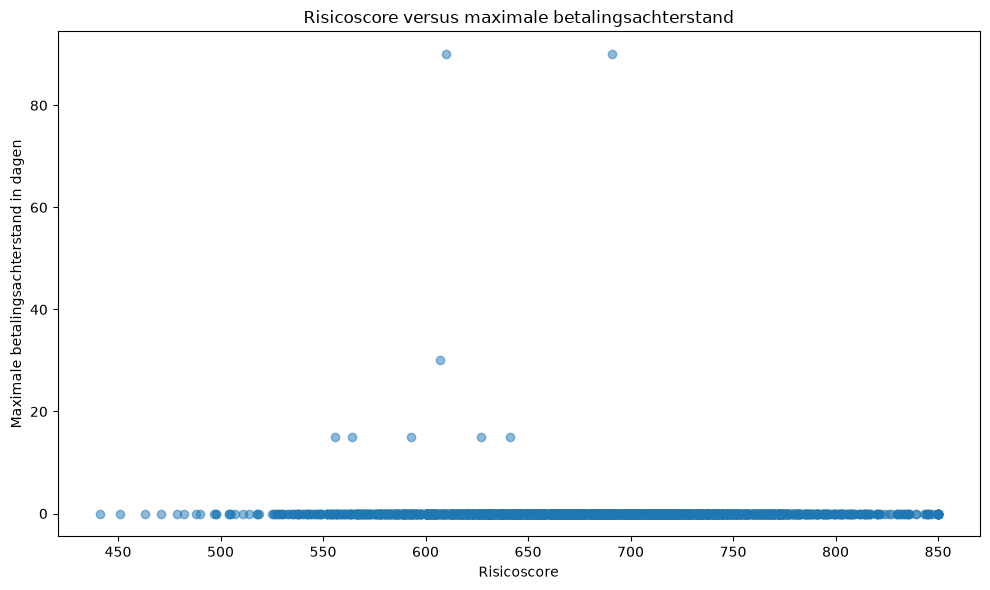

In [163]:
plt.figure(figsize=(10, 6))
 
plt.scatter(
    customers["risk_score"],
    customers["max_days_past_due"],
    alpha=0.5
)
 
plt.title("Risicoscore versus maximale betalingsachterstand")
plt.xlabel("Risicoscore")
plt.ylabel("Maximale betalingsachterstand in dagen")
plt.tight_layout()
 
plt.savefig(
    images_dir / "risk_score_vs_days_past_due.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()

### 8.10 — Gemiddeld klantprofiel per monitoring level

In [164]:
monitoring_profile = (
    risk
    .groupby("monitoring_level")
    .agg(
        aantal_klanten=("customer_id", "count"),
        gemiddeld_inkomen_eur=("annual_income_eur", "mean"),
        gemiddelde_risk_score=("risk_score", "mean"),
        gemiddeld_openstaand_krediet_eur=(
            "openstaand_krediet_eur",
            "mean"
        ),
        gemiddeld_days_past_due=(
            "max_days_past_due",
            "mean"
        ),
        gemiddeld_defaults=(
            "aantal_defaults",
            "mean"
        ),
        gemiddeld_suspicious=(
            "suspicious_transacties",
            "mean"
        )
    )
)
 
display(
    monitoring_profile.round(2)
)

,aantal_klanten,gemiddeld_inkomen_eur,gemiddelde_risk_score,gemiddeld_openstaand_krediet_eur,gemiddeld_days_past_due,gemiddeld_defaults,gemiddeld_suspicious
monitoring_level,,,,,,,
High,2,48100.00,650.50,6720.03,90.00,1.0,0.0
Medium,325,46311.69,585.69,3863.93,0.23,0.0,0.2
Normal,2173,54709.34,696.87,3022.61,0.01,0.0,0.0


### 8.11 — Openstaand krediet per monitoring level

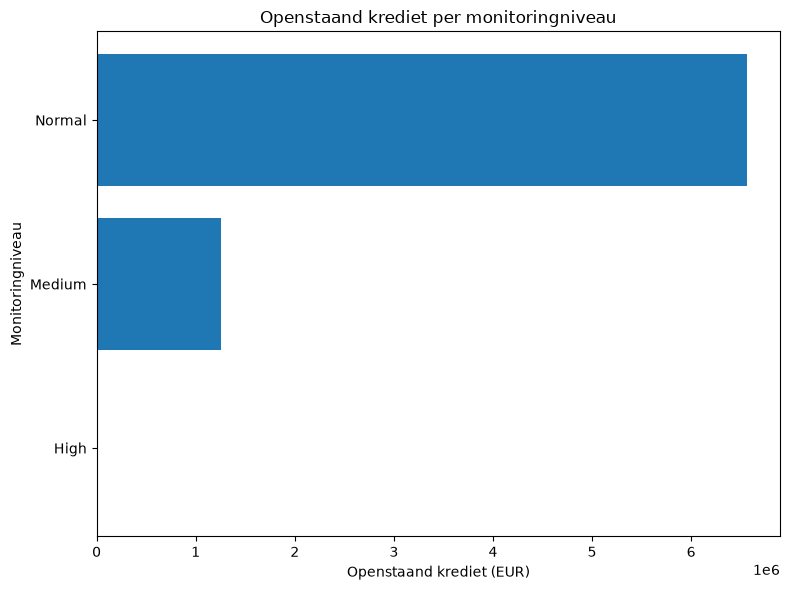

In [165]:
credit_by_monitoring = (
    risk
    .groupby("monitoring_level")[
        "openstaand_krediet_eur"
    ]
    .sum()
    .sort_values(ascending=True)
)
 
plt.figure(figsize=(8, 6))
 
plt.barh(
    credit_by_monitoring.index,
    credit_by_monitoring.values
)
 
plt.title("Openstaand krediet per monitoringniveau")
plt.xlabel("Openstaand krediet (EUR)")
plt.ylabel("Monitoringniveau")
plt.tight_layout()
 
plt.savefig(
    images_dir / "outstanding_credit_by_monitoring_level.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()

### 8.12 — Klanten met gecombineerd verhoogd risico

In [166]:
combined_risk = customers[
    (
        customers["risk_score"] < 600
    )
    |
    (
        customers["max_days_past_due"] >= 30
    )
    |
    (
        customers["aantal_defaults"] > 0
    )
    |
    (
        customers["suspicious_transacties"] > 0
    )
].copy()
 
combined_risk["risk_signal_count"] = (
    (combined_risk["risk_score"] < 600).astype(int)
    +
    (combined_risk["max_days_past_due"] >= 30).astype(int)
    +
    (combined_risk["aantal_defaults"] > 0).astype(int)
    +
    (combined_risk["suspicious_transacties"] > 0).astype(int)
)
 
combined_risk = combined_risk.sort_values(
    [
        "risk_signal_count",
        "aantal_defaults",
        "max_days_past_due",
        "suspicious_transacties",
        "openstaand_krediet_eur"
    ],
    ascending=[
        False,
        False,
        False,
        False,
        False
    ]
)
 
display(
    combined_risk[
        [
            "customer_id",
            "segment",
            "annual_income_eur",
            "risk_score",
            "openstaand_krediet_eur",
            "max_days_past_due",
            "aantal_defaults",
            "suspicious_transacties",
            "risk_signal_count"
        ]
    ]
    .head(25)
)

,customer_id,segment,annual_income_eur,risk_score,openstaand_krediet_eur,max_days_past_due,aantal_defaults,suspicious_transacties,risk_signal_count
1312,C01313,Affluent,45000,610,12435.059570,90,1,0,2
1964,C01965,Mass Market,51200,691,1005.000000,90,1,0,2
573,C00574,Mass Market,59900,593,6984.919922,15,0,1,2
1742,C01743,Affluent,58300,588,33438.648438,0,0,1,2
2406,C02407,Young Professional,40000,561,9974.219727,0,0,1,2
1456,C01457,Mass Market,30100,538,2506.030029,0,0,1,2
224,C00225,Mass Market,46600,548,0.000000,0,0,1,2
244,C00245,Family,68600,569,0.000000,0,0,1,2
680,C00681,Young Professional,39400,538,0.000000,0,0,1,2
1481,C01482,Mass Market,27100,564,0.000000,0,0,1,2


### 8.13 — Verdeling aantal risicosignalen

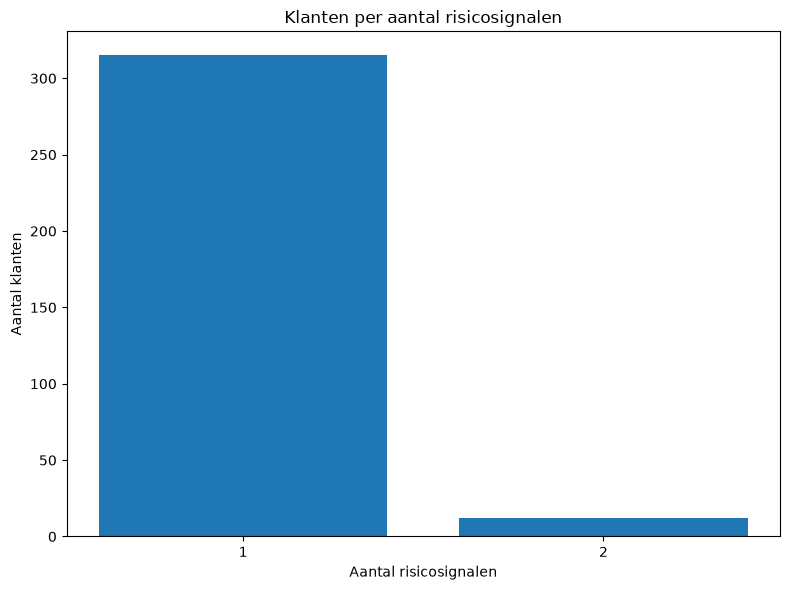

,customers
risk_signal_count,
1,315
2,12


In [167]:
risk_signal_distribution = (
    combined_risk["risk_signal_count"]
    .value_counts()
    .sort_index()
)
 
plt.figure(figsize=(8, 6))
 
plt.bar(
    risk_signal_distribution.index.astype(str),
    risk_signal_distribution.values
)
 
plt.title("Klanten per aantal risicosignalen")
plt.xlabel("Aantal risicosignalen")
plt.ylabel("Aantal klanten")
plt.tight_layout()
 
plt.savefig(
    images_dir / "customers_by_risk_signals.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()
 
display(
    risk_signal_distribution
    .to_frame("customers")
)

### 8.14 — Samenvatting deeper analysis

In [168]:
deeper_analysis_summary = pd.Series(
    {
        "Customer Count":
            len(customers),
 
        "Customers With Risk Signal":
            len(combined_risk),
 
        "Customers With 2+ Risk Signals":
            (combined_risk["risk_signal_count"] >= 2).sum(),
 
        "Customers With 3+ Risk Signals":
            (combined_risk["risk_signal_count"] >= 3).sum(),
 
        "Correlatie Income vs Risicoscore":
            customers[
                [
                    "annual_income_eur",
                    "risk_score"
                ]
            ].corr().iloc[0, 1],
 
        "Correlatie Risicoscore versus openstaand krediet":
            customers[
                [
                    "risk_score",
                    "openstaand_krediet_eur"
                ]
            ].corr().iloc[0, 1],
 
        "Correlatie Risicoscore vs Days Past Due":
            customers[
                [
                    "risk_score",
                    "max_days_past_due"
                ]
            ].corr().iloc[0, 1]
    }
)
 
display(
    deeper_analysis_summary
    .round(3)
    .to_frame("Value")
)

,Value
Customer Count,2500.000
Customers With Risk Signal,327.000
Customers With 2+ Risk Signals,12.000
Customers With 3+ Risk Signals,0.000
Correlatie Income vs Risicoscore,0.257
Correlatie Risicoscore versus openstaand krediet,-0.032
Correlatie Risicoscore vs Days Past Due,-0.032


## 9 — Finale Portfoliovisualisaties & Businessinzichten

In [169]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
 
project_root = Path.cwd()
if project_root.name.lower() == "notebooks":
    project_root = project_root.parent

images_dir = project_root / "Images"
images_dir.mkdir(parents=True, exist_ok=True)
 
outputs_dir = project_root / "Outputs"
outputs_dir.mkdir(parents=True, exist_ok=True)

### 9.1 — Executive KPI summary

In [170]:
total_customers = len(customers)
total_transactions = len(transactions)
total_loans = len(loans)
 
total_inflow = (
    transactions.loc[
        transactions["flow_direction"] == "Inflow",
        "amount_eur"
    ]
    .sum()
)
 
total_outflow = abs(
    transactions.loc[
        transactions["flow_direction"] == "Outflow",
        "amount_eur"
    ]
    .sum()
)
 
net_cashflow = transactions["amount_eur"].sum()
 
total_outstanding_credit = (
    loans["outstanding_balance_eur"]
    .sum()
)
 
default_rate = (
    loans["default_flag"]
    .astype(int)
    .mean()
    * 100
)
 
suspicious_rate = (
    transactions["is_suspicious"]
    .astype(int)
    .mean()
    * 100
)
 
international_rate = (
    transactions["is_international"]
    .astype(int)
    .mean()
    * 100
)
 
executive_kpis = pd.DataFrame(
    {
        "KPI": [
            "Customers",
            "Transactions",
            "Loans",
            "Total Inflow EUR",
            "Total Outflow EUR",
            "Net Cash Flow EUR",
            "Outstanding Credit EUR",
            "Default Rate %",
            "Suspicious Transaction Rate %",
            "International Transaction Rate %"
        ],
 
        "Value": [
            total_customers,
            total_transactions,
            total_loans,
            total_inflow,
            total_outflow,
            net_cashflow,
            total_outstanding_credit,
            default_rate,
            suspicious_rate,
            international_rate
        ]
    }
)
 
display(
    executive_kpis.round(2)
)

,KPI,Value
0,Customers,2500.00
1,Transactions,10000.00
2,Loans,700.00
3,Total Inflow EUR,2568930.19
4,Total Outflow EUR,1458036.58
5,Net Cash Flow EUR,1110893.61
6,Outstanding Credit EUR,7837348.11
7,Default Rate %,0.29
8,Suspicious Transaction Rate %,0.65
9,International Transaction Rate %,1.91


### 9.2 — Finale maandelijkse cashflowgrafiek

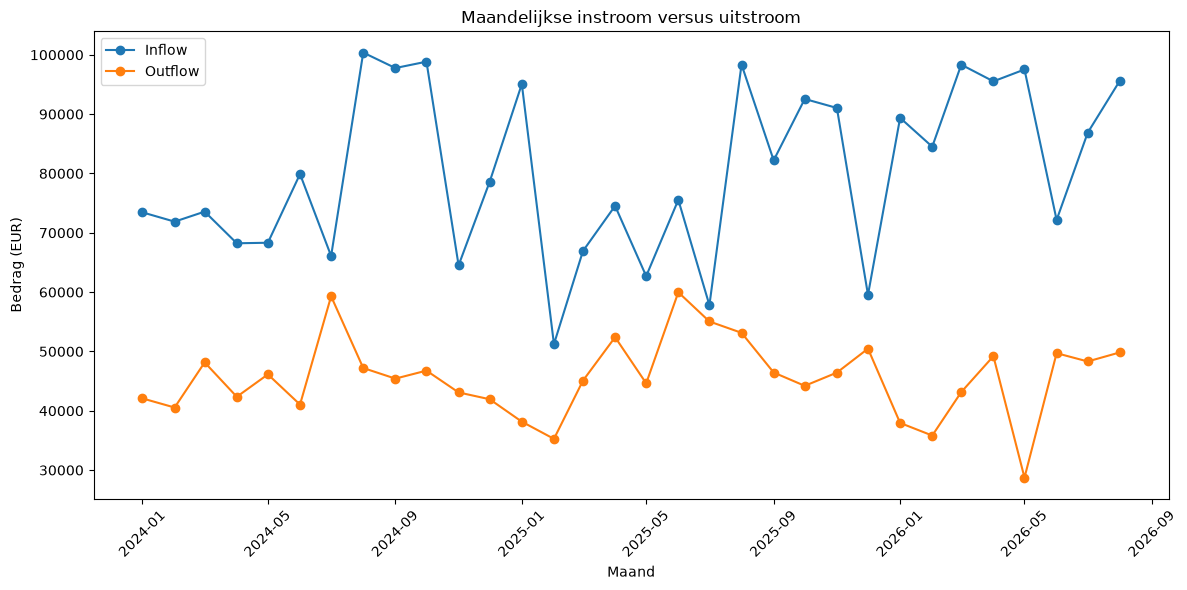

In [171]:
monthly_final = (
    monthly
    .sort_values("maand")
    .copy()
)
 
plt.figure(figsize=(12, 6))
 
plt.plot(
    monthly_final["maand"],
    monthly_final["inflow_eur"],
    marker="o",
    label="Inflow"
)
 
plt.plot(
    monthly_final["maand"],
    monthly_final["outflow_eur"],
    marker="o",
    label="Outflow"
)
 
plt.title("Maandelijkse instroom versus uitstroom")
plt.xlabel("Maand")
plt.ylabel("Bedrag (EUR)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
 
plt.savefig(
    images_dir / "FINAL_monthly_inflow_vs_outflow.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()

### 9.3 — Finale grafiek: uitgaven per categorie

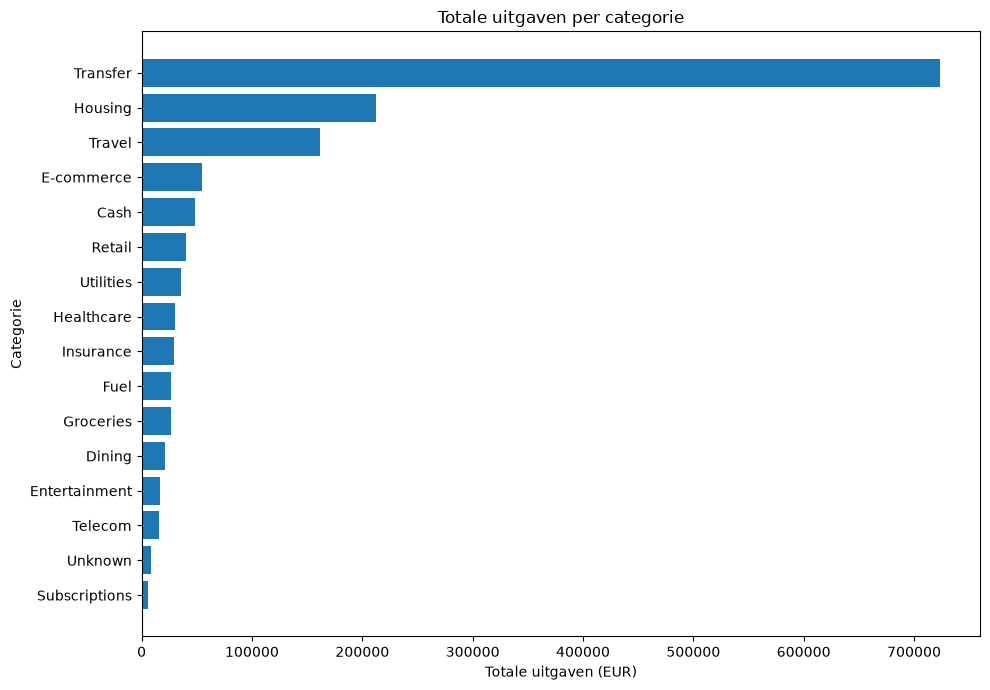

In [172]:
final_category_spending = (
    transactions[
        transactions["flow_direction"] == "Outflow"
    ]
    .groupby("category")["amount_eur"]
    .sum()
    .abs()
    .sort_values(ascending=True)
)
 
plt.figure(figsize=(10, 7))
 
plt.barh(
    final_category_spending.index,
    final_category_spending.values
)
 
plt.title("Totale uitgaven per categorie")
plt.xlabel("Totale uitgaven (EUR)")
plt.ylabel("Categorie")
plt.tight_layout()
 
plt.savefig(
    images_dir / "FINAL_spending_by_category.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()

### 9.4 — Finale klantsegment summary

In [173]:
final_segment_summary = (
    customers
    .groupby("segment")
    .agg(
        customers=("customer_id", "count"),
 
        avg_income_eur=(
            "annual_income_eur",
            "mean"
        ),
 
        avg_risk_score=(
            "risk_score",
            "mean"
        ),
 
        avg_accounts=(
            "aantal_accounts",
            "mean"
        ),
 
        avg_loans=(
            "aantal_leningen",
            "mean"
        ),
 
        avg_net_cashflow_eur=(
            "netto_cashflow_eur",
            "mean"
        ),
 
        avg_outstanding_credit_eur=(
            "openstaand_krediet_eur",
            "mean"
        ),
 
        suspicious_transactions=(
            "suspicious_transacties",
            "sum"
        ),
 
        digital_adoption_pct=(
            "digital_active",
            "mean"
        )
    )
)
 
final_segment_summary[
    "digital_adoption_pct"
] *= 100
 
display(
    final_segment_summary.round(2)
)

,customers,avg_income_eur,avg_risk_score,avg_accounts,avg_loans,avg_net_cashflow_eur,avg_outstanding_credit_eur,suspicious_transactions,digital_adoption_pct
segment,,,,,,,,,
Affluent,312,85636.86,708.57,1.67,0.28,840.37,3506.47,6,79.49
Family,608,48987.01,677.34,1.64,0.29,436.74,3203.93,20,77.63
Mass Market,904,48538.38,679.42,1.60,0.28,385.39,3022.17,20,78.98
Senior,215,48071.16,677.24,1.63,0.28,459.59,2936.12,7,81.40
Young Professional,461,50572.89,679.49,1.68,0.27,294.92,3106.36,12,75.70


### 9.5 — Finale grafiek: gemiddeld inkomen per segment

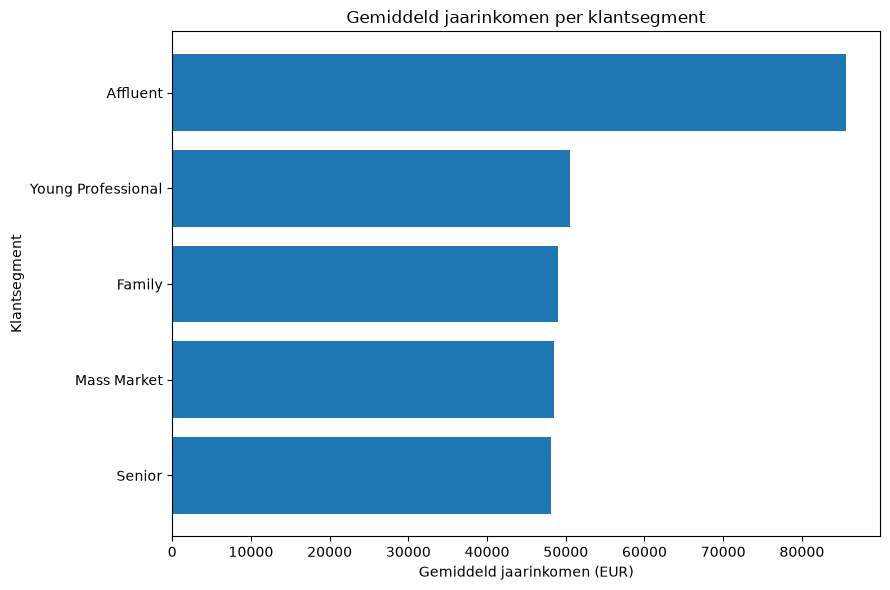

In [174]:
final_income_segment = (
    final_segment_summary["avg_income_eur"]
    .sort_values(ascending=True)
)
 
plt.figure(figsize=(9, 6))
 
plt.barh(
    final_income_segment.index,
    final_income_segment.values
)
 
plt.title("Gemiddeld jaarinkomen per klantsegment")
plt.xlabel("Gemiddeld jaarinkomen (EUR)")
plt.ylabel("Klantsegment")
plt.tight_layout()
 
plt.savefig(
    images_dir / "FINAL_income_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()

### 9.6 — Finale credit risk summary

In [175]:
loans["default_flag"] = (
    loans["default_flag"]
    .astype(int)
)
 
loans["risk_group"] = pd.cut(
    loans["customer_risk_score"],
 
    bins=[
        -float("inf"),
        600,
        700,
        float("inf")
    ],
 
    labels=[
        "High Risk",
        "Medium Risk",
        "Low Risk"
    ],
 
    right=False
)
 
final_credit_risk = (
    loans
    .groupby(
        "risk_group",
        observed=False
    )
    .agg(
        aantal_leningen=(
            "loan_id",
            "count"
        ),
 
        aantal_defaults=(
            "default_flag",
            "sum"
        ),
 
        default_rate=(
            "default_flag",
            "mean"
        ),
 
        outstanding_credit_eur=(
            "outstanding_balance_eur",
            "sum"
        ),
 
        avg_interest_rate_pct=(
            "interest_rate_pct",
            "mean"
        )
    )
)
 
final_credit_risk[
    "default_rate_pct"
] = (
    final_credit_risk["default_rate"]
    * 100
)
 
display(
    final_credit_risk[
        [
            "aantal_leningen",
            "aantal_defaults",
            "default_rate_pct",
            "outstanding_credit_eur",
            "avg_interest_rate_pct"
        ]
    ].round(2)
)

,aantal_leningen,aantal_defaults,default_rate_pct,outstanding_credit_eur,avg_interest_rate_pct
risk_group,,,,,
High Risk,84,0,0.0,1008091.40,9.13
Medium Risk,333,2,0.6,3754698.69,7.55
Low Risk,283,0,0.0,3074558.02,6.28


### 9.7 — Finale grafiek: default rate per risicogroep

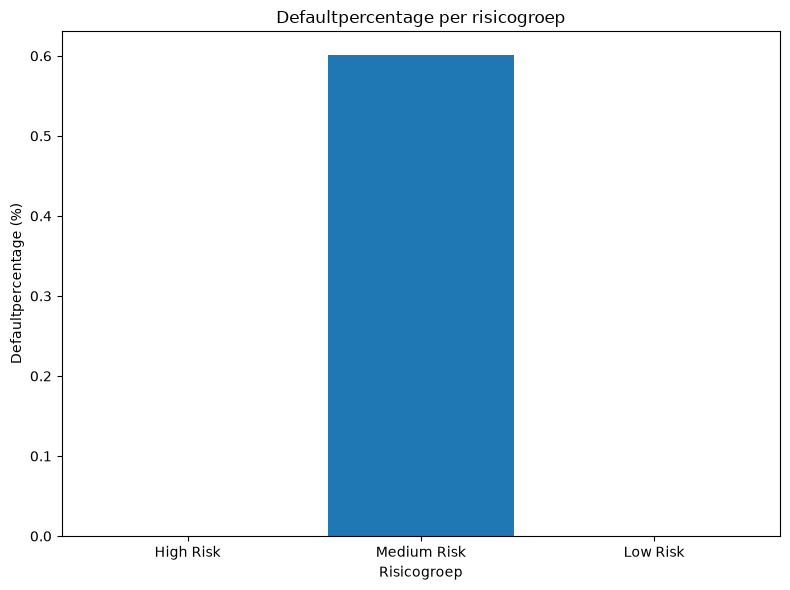

In [176]:
plt.figure(figsize=(8, 6))
 
plt.bar(
    final_credit_risk.index.astype(str),
    final_credit_risk["default_rate_pct"]
)
 
plt.title("Defaultpercentage per risicogroep")
plt.xlabel("Risicogroep")
plt.ylabel("Defaultpercentage (%)")
plt.tight_layout()
 
plt.savefig(
    images_dir / "FINAL_default_rate_by_risk_group.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()

### 9.8 — Finale suspicious transaction summary

In [177]:
transactions["is_suspicious"] = (
    transactions["is_suspicious"]
    .astype(int)
)
 
transactions["is_international"] = (
    transactions["is_international"]
    .astype(int)
)
 
final_suspicious_channel = (
    transactions
    .groupby("channel")
    .agg(
        transactions=(
            "transaction_id",
            "count"
        ),
 
        suspicious_transactions=(
            "is_suspicious",
            "sum"
        ),
 
        suspicious_rate=(
            "is_suspicious",
            "mean"
        )
    )
)
 
final_suspicious_channel[
    "suspicious_rate_pct"
] = (
    final_suspicious_channel[
        "suspicious_rate"
    ]
    * 100
)
 
final_suspicious_channel = (
    final_suspicious_channel
    .sort_values(
        "suspicious_rate_pct",
        ascending=True
    )
)
 
display(
    final_suspicious_channel[
        [
            "transactions",
            "suspicious_transactions",
            "suspicious_rate_pct"
        ]
    ].round(2)
)

,transactions,suspicious_transactions,suspicious_rate_pct
channel,,,
ATM,451,0,0.00
Direct Debit,1217,4,0.33
Card Present,1893,8,0.42
Mobile App,2839,16,0.56
Bank Transfer,2517,15,0.60
Online,1083,22,2.03


### 9.9 — Finale grafiek: suspicious rate per kanaal

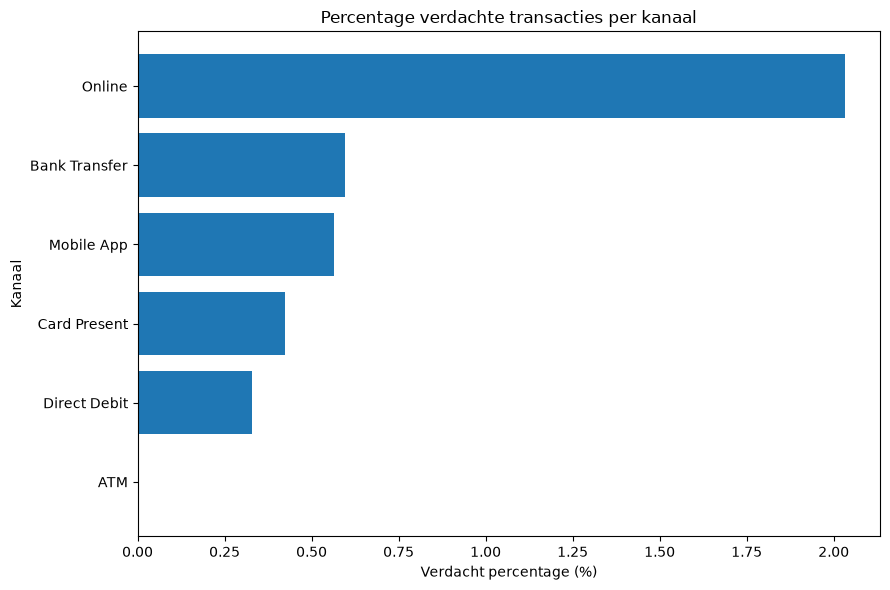

In [178]:
plt.figure(figsize=(9, 6))
 
plt.barh(
    final_suspicious_channel.index,
    final_suspicious_channel[
        "suspicious_rate_pct"
    ]
)
 
plt.title("Percentage verdachte transacties per kanaal")
plt.xlabel("Verdacht percentage (%)")
plt.ylabel("Kanaal")
plt.tight_layout()
 
plt.savefig(
    images_dir / "FINAL_suspicious_rate_by_channel.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()

### 9.10 — Domestic versus international suspicious rate

In [179]:
scope_analysis = (
    transactions
    .assign(
        transaction_scope=
        transactions[
            "is_international"
        ].map(
            {
                0: "Domestic",
                1: "International"
            }
        )
    )
    .groupby("transaction_scope")
    .agg(
        transactions=(
            "transaction_id",
            "count"
        ),
 
        suspicious_transactions=(
            "is_suspicious",
            "sum"
        ),
 
        suspicious_rate=(
            "is_suspicious",
            "mean"
        )
    )
)
 
scope_analysis[
    "suspicious_rate_pct"
] = (
    scope_analysis["suspicious_rate"]
    * 100
)
 
display(
    scope_analysis[
        [
            "transactions",
            "suspicious_transactions",
            "suspicious_rate_pct"
        ]
    ].round(2)
)

,transactions,suspicious_transactions,suspicious_rate_pct
transaction_scope,,,
Domestic,9809,59,0.60
International,191,6,3.14


### 9.11 — Monitoring level summary

In [180]:
monitoring_summary = (
    risk
    .groupby("monitoring_level")
    .agg(
        customers=(
            "customer_id",
            "count"
        ),
 
        outstanding_credit_eur=(
            "openstaand_krediet_eur",
            "sum"
        ),
 
        defaults=(
            "aantal_defaults",
            "sum"
        ),
 
        suspicious_transactions=(
            "suspicious_transacties",
            "sum"
        )
    )
)
 
monitoring_summary[
    "customer_pct"
] = (
    monitoring_summary["customers"]
    / monitoring_summary["customers"].sum()
    * 100
)
 
display(
    monitoring_summary.round(2)
)

,customers,outstanding_credit_eur,defaults,suspicious_transactions,customer_pct
monitoring_level,,,,,
High,2,13440.06,2,0,0.08
Medium,325,1255777.30,0,65,13.00
Normal,2173,6568130.75,0,0,86.92


### 9.12 — Finale grafiek monitoring levels

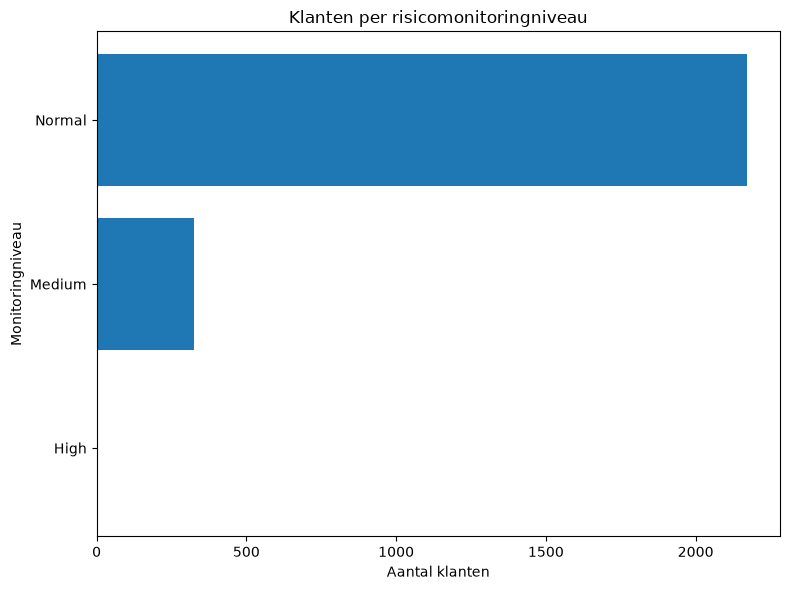

In [181]:
monitoring_plot = (
    monitoring_summary["customers"]
    .sort_values(ascending=True)
)
 
plt.figure(figsize=(8, 6))
 
plt.barh(
    monitoring_plot.index,
    monitoring_plot.values
)
 
plt.title("Klanten per risicomonitoringniveau")
plt.xlabel("Aantal klanten")
plt.ylabel("Monitoringniveau")
plt.tight_layout()
 
plt.savefig(
    images_dir / "FINAL_customers_by_monitoring_level.png",
    dpi=300,
    bbox_inches="tight"
)
 
plt.show()

### 9.13 — Beste en belangrijkste resultaten automatisch bepalen

In [182]:
top_spending_category = (
    final_category_spending
    .idxmax()
)
 
top_spending_amount = (
    final_category_spending
    .max()
)
 
highest_income_segment = (
    final_segment_summary[
        "avg_income_eur"
    ]
    .idxmax()
)
 
highest_income = (
    final_segment_summary[
        "avg_income_eur"
    ]
    .max()
)
 
highest_digital_segment = (
    final_segment_summary[
        "digital_adoption_pct"
    ]
    .idxmax()
)
 
highest_digital_rate = (
    final_segment_summary[
        "digital_adoption_pct"
    ]
    .max()
)
 
highest_default_group = (
    final_credit_risk[
        "default_rate_pct"
    ]
    .idxmax()
)
 
highest_default_rate = (
    final_credit_risk[
        "default_rate_pct"
    ]
    .max()
)
 
highest_suspicious_channel = (
    final_suspicious_channel[
        "suspicious_rate_pct"
    ]
    .idxmax()
)
 
highest_suspicious_channel_rate = (
    final_suspicious_channel[
        "suspicious_rate_pct"
    ]
    .max()
)
 
busiest_month_row = (
    monthly_final.loc[
        monthly_final[
            "aantal_transacties"
        ].idxmax()
    ]
)
 
busiest_month = (
    busiest_month_row["maand"]
)
 
busiest_month_transactions = (
    busiest_month_row[
        "aantal_transacties"
    ]
)

### 9.14 — Business insights automatisch genereren

In [183]:
business_insights = [
 
    (
        f"1. {top_spending_category} was de grootste "
        f"uitgavencategorie met ongeveer "
        f"€{top_spending_amount:,.2f} aan totale uitgaven."
    ),
 
    (
        f"2. Het segment {highest_income_segment} had het "
        f"hoogste gemiddelde jaarinkomen: "
        f"ongeveer €{highest_income:,.2f}."
    ),
 
    (
        f"3. {highest_digital_segment} had de hoogste digitale "
        f"adoptie, met ongeveer "
        f"{highest_digital_rate:.2f}% digitaal actieve klanten."
    ),
 
    (
        f"4. De risicogroep '{highest_default_group}' had de "
        f"hoogste default rate: "
        f"{highest_default_rate:.2f}%."
    ),
 
    (
        f"5. Het transactiekanaal '{highest_suspicious_channel}' "
        f"had de hoogste suspicious transaction rate: "
        f"{highest_suspicious_channel_rate:.2f}%."
    ),
 
    (
        f"6. De drukste maand was "
        f"{pd.to_datetime(busiest_month).strftime('%B %Y')} "
        f"met {int(busiest_month_transactions):,} transacties."
    ),
 
    (
        f"7. De totale portefeuille bevat "
        f"€{total_outstanding_credit:,.2f} aan openstaand krediet."
    ),
 
    (
        f"8. Over alle transacties heen bedroeg de suspicious "
        f"transaction rate {suspicious_rate:.2f}%."
    )
]
 
print("FINALE BUSINESSINZICHTEN")
print("=" * 60)
 
for insight in business_insights:
    print(insight)

FINALE BUSINESSINZICHTEN
1. Transfer was de grootste uitgavencategorie met ongeveer €723,596.11 aan totale uitgaven.
2. Het segment Affluent had het hoogste gemiddelde jaarinkomen: ongeveer €85,636.86.
3. Senior had de hoogste digitale adoptie, met ongeveer 81.40% digitaal actieve klanten.
4. De risicogroep 'Medium Risk' had de hoogste default rate: 0.60%.
5. Het transactiekanaal 'Online' had de hoogste suspicious transaction rate: 2.03%.
6. De drukste maand was August 2025 met 363 transacties.
7. De totale portefeuille bevat €7,837,348.11 aan openstaand krediet.
8. Over alle transacties heen bedroeg de suspicious transaction rate 0.65%.


### 9.15 — Correlatie-waarschuwing voor portfolio

In [184]:
print("\nANALYTISCHE NOTA")
print("=" * 60)
 
print(
    "Correlaties and observed differences should be interpreted "
    "as associations within this synthetic dataset. "
    "They do not establish causal relationships."
)


ANALYTISCHE NOTA
Correlaties and observed differences should be interpreted as associations within this synthetic dataset. They do not establish causal relationships.


### 9.16 — Tabellen exporteren voor GitHub / portfolio

In [185]:
executive_kpis.to_csv(
    outputs_dir / "executive_kpis.csv",
    index=False
)
 
final_segment_summary.to_csv(
    outputs_dir / "customer_segment_summary.csv"
)
 
final_credit_risk.to_csv(
    outputs_dir / "credit_risk_summary.csv"
)
 
final_suspicious_channel.to_csv(
    outputs_dir / "suspicious_channel_summary.csv"
)
 
monitoring_summary.to_csv(
    outputs_dir / "risk_monitoring_summary.csv"
)
 
scope_analysis.to_csv(
    outputs_dir / "domestic_international_summary.csv"
)

### 9.17 — Business insights exporteren naar tekstbestand

In [186]:
with open(
    outputs_dir / "business_insights.txt",
    "w",
    encoding="utf-8"
) as file:
 
    file.write(
        "FinSight - Final Business Insights\n"
    )
 
    file.write(
        "=" * 50 + "\n\n"
    )
 
    for insight in business_insights:
        file.write(
            insight + "\n"
        )
 
    file.write(
        "\nAnalytical note:\n"
    )
 
    file.write(
        "All data is synthetic. Correlatie does not imply causation."
    )

### 9.18 — Geselecteerde portfolio visuals oplijsten

In [187]:
portfolio_visuals = [
 
    "FINAL_monthly_inflow_vs_outflow.png",
 
    "FINAL_spending_by_category.png",
 
    "FINAL_income_by_segment.png",
 
    "FINAL_default_rate_by_risk_group.png",
 
    "FINAL_suspicious_rate_by_channel.png",
 
    "FINAL_customers_by_monitoring_level.png",
 
    "customer_correlation_matrix.png",
 
    "loan_delinquency_distribution.png"
]
 
print("\nGESELECTEERDE PORTFOLIOVISUALISATIES")
print("=" * 60)
 
for visual in portfolio_visuals:
    print(visual)


GESELECTEERDE PORTFOLIOVISUALISATIES
FINAL_monthly_inflow_vs_outflow.png
FINAL_spending_by_category.png
FINAL_income_by_segment.png
FINAL_default_rate_by_risk_group.png
FINAL_suspicious_rate_by_channel.png
FINAL_customers_by_monitoring_level.png
customer_correlation_matrix.png
loan_delinquency_distribution.png


### 9.19 — Geselecteerde portfolio visuals oplijsten

In [188]:
print("\n" + "=" * 60)
 
print(
    "FINSIGHT ANALYTICSPROJECT - PYTHONANALYSE VOLTOOID"
)
 
print("=" * 60)
 
print(
    f"Geanalyseerde klanten: {total_customers:,}"
)
 
print(
    f"Geanalyseerde transacties: {total_transactions:,}"
)
 
print(
    f"Geanalyseerde leningen: {total_loans:,}"
)
 
print(
    f"Grafieken opgeslagen in: {images_dir.name}/"
)
 
print(
    f"Samenvattingsbestanden opgeslagen in: {outputs_dir.name}/"
)


FINSIGHT ANALYTICSPROJECT - PYTHONANALYSE VOLTOOID
Geanalyseerde klanten: 2,500
Geanalyseerde transacties: 10,000
Geanalyseerde leningen: 700
Grafieken opgeslagen in: Images/
Samenvattingsbestanden opgeslagen in: Outputs/


# Conclusie

FinSight demonstreert een end-to-end analyseworkflow waarin SQL Server en Python worden gecombineerd. SQL wordt gebruikt om de bankdata te valideren, op te schonen, te aggregeren en analytisch te modelleren. Python wordt vervolgens gebruikt voor verkennende analyse, visualisatie en verdere analyse van klantgedrag, kredietrisico en patronen in verdachte transacties.

Omdat de dataset synthetisch is, demonstreert het project vooral analytische methoden en workflow, en worden er geen uitspraken gedaan over echte bankklanten. Correlaties en verschillen tussen groepen moeten worden geïnterpreteerd als verbanden binnen deze synthetische dataset en niet als bewijs voor causaliteit.